In [1]:
# ============================================================
# CELL 1 — IMPORT LIBRARIES
# ============================================================

from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 160)
pd.set_option("display.max_colwidth", 60)

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# ============================================================
# CELL 2 — PROJECT PATHS
# ============================================================

NOTEBOOK_DIR = Path.cwd()

# If running from the notebooks directory
if NOTEBOOK_DIR.name.lower() == "notebooks":
    PROJECT_ROOT = NOTEBOOK_DIR.parent
else:
    # Fallback: locate Crime_Analysis folder
    candidates = [
        NOTEBOOK_DIR,
        NOTEBOOK_DIR.parent,
        NOTEBOOK_DIR.parent.parent
    ]

    PROJECT_ROOT = None

    for candidate in candidates:
        if (
            candidate.name.lower() == "crime_analysis"
            and (candidate / "data").exists()
        ):
            PROJECT_ROOT = candidate
            break

    if PROJECT_ROOT is None:
        PROJECT_ROOT = NOTEBOOK_DIR

DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed"
OUTPUTS_DIR = PROJECT_ROOT / "outputs"

FIGURES_DIR = OUTPUTS_DIR / "figures"
TABLES_DIR = OUTPUTS_DIR / "tables"

FINAL_DATA_PATH = (
    PROCESSED_DIR /
    "district_integrated_final.csv"
)

# Create output directories if required
FIGURES_DIR.mkdir(
    parents=True,
    exist_ok=True
)

TABLES_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print("=" * 80)
print("PROJECT PATHS")
print("=" * 80)

print("Project root :", PROJECT_ROOT.resolve())
print("Final data   :", FINAL_DATA_PATH.resolve())
print("Figures      :", FIGURES_DIR.resolve())
print("Tables       :", TABLES_DIR.resolve())

PROJECT PATHS
Project root : D:\Major_Project\Crime_Analysis
Final data   : D:\Major_Project\Crime_Analysis\data\processed\district_integrated_final.csv
Figures      : D:\Major_Project\Crime_Analysis\outputs\figures
Tables       : D:\Major_Project\Crime_Analysis\outputs\tables


In [3]:
# ============================================================
# CELL 3 — LOAD FINALIZED DATASET
# ============================================================

assert FINAL_DATA_PATH.exists(), (
    f"Final dataset not found:\n{FINAL_DATA_PATH}"
)

df = pd.read_csv(
    FINAL_DATA_PATH,
    low_memory=False
)

print("=" * 80)
print("FINAL DATASET LOADED")
print("=" * 80)

print(
    f"\nRows    : {df.shape[0]:,}"
)

print(
    f"Columns : {df.shape[1]:,}"
)

print(
    f"\nFile:"
)

print(
    FINAL_DATA_PATH.resolve()
)

FINAL DATASET LOADED

Rows    : 9,856
Columns : 331

File:
D:\Major_Project\Crime_Analysis\data\processed\district_integrated_final.csv


In [4]:
# ============================================================
# CELL 4 — INITIAL DATASET OVERVIEW
# ============================================================

print("=" * 80)
print("INITIAL DATASET OVERVIEW")
print("=" * 80)

print("\nFirst 5 rows:")
display(df.head())

print("\nLast 5 rows:")
display(df.tail())

print("\nDataset shape:")
print(df.shape)

print("\nColumn names:")
print(df.columns.tolist())

INITIAL DATASET OVERVIEW

First 5 rows:


,STATE,UNIT_NAME,YEAR,IPC_MURDER,IPC_ATTEMPT_TO_MURDER,IPC_RAPE,IPC_OTHER_RAPE,IPC_KIDNAPPING_AND_ABDUCTION_OF_WOMEN_AND_GIRLS,IPC_KIDNAPPING_AND_ABDUCTION_OF_OTHERS,IPC_DACOITY,IPC_PREPARATION_AND_ASSEMBLY_FOR_DACOITY,IPC_ROBBERY,IPC_BURGLARY,IPC_THEFT,IPC_OTHER_THEFT,IPC_RIOTS,IPC_CHEATING,IPC_COUNTERFIETING,IPC_ARSON,IPC_HURT_GREVIOUS_HURT,IPC_INSULT_TO_MODESTY_OF_WOMEN,IPC_IMPORTATION_OF_GIRLS_FROM_FOREIGN_COUNTRIES,IPC_TOTAL_IPC_CRIMES,IPC_ATTEMPT_TO_COMMIT_MURDER,IPC_ATTEMPT_TO_COMMIT_CULPABLE_HOMICIDE,IPC_CUSTODIAL_GANG_RAPE,IPC_CUSTODIAL_OTHER_RAPE,IPC_RAPE_OTHER_THAN_CUSTODIAL,IPC_RAPE_GANG_RAPE,IPC_RAPE_OTHERS,IPC_ATTEMPT_TO_COMMIT_RAPE,IPC_KIDNAPPING_ABDUCTION_TOTAL,IPC_KIDNAPPING_ABDUCTION_IN_ORDER_TO_MURDER,IPC_KIDNAPPING_FOR_RANSOM,IPC_KIDNAPPING_ABDUCTION_OF_WOMEN_TO_COMPEL_HER_FOR_MARRIAGE,IPC_OTHER_KIDNAPPING,IPC_DACOITY_WITH_MURDER,IPC_OTHER_DACOITY,IPC_MAKING_PREPARATION_AND_ASSEMBLY_FOR_COMMITTING_DACOITY,IPC_CRIMINAL_TRESPASS_BURGLARY,IPC_CRIMINAL_TRESPASS_OR_BURGLARY,IPC_HOUSE_TRESPASS_HOUSE_BREAKING,IPC_OTHER_THEFTS,IPC_UNLAWFUL_ASSEMBLY,IPC_RIOTS_COMMUNAL,IPC_RIOTS_INDUSTRIAL,IPC_RIOTS_POLITICAL,IPC_RIOTS_CASTE_CONFLICT,IPC_RIOTS_SC_STS_VS_NON_SCS_STS,IPC_RIOTS_OTHER_CASTE_CONFLICT,...,WOMEN_IN_PLACES_RELATED_TO_WORK,WOMEN_IN_PUBLIC_TRANSPORT_SYSTEM,WOMEN_IN_OTHER_PLACES,WOMEN_IMPORTATION_OF_GIRLS_FROM_FOREIGN_COUNTRY,WOMEN_MURDER,WOMEN_ATTEMPT_TO_COMMIT_MURDER,WOMEN_CULPABLE_HOMICIDE_NOT_AMOUNTING_TO_MURDER,WOMEN_ATTEMPT_TO_COMMIT_CULPABLE_HOMICIDE,WOMEN_GRIEVOUS_HURT,WOMEN_HURT,WOMEN_ACID_ATTACK,WOMEN_ATTEMPT_TO_ACID_ATTACK,WOMEN_DEATHS_CAUSED_WITH_INTENT_TO_CAUSE_MISCARRIAGE,WOMEN_CAUSING_MISCARRIAGE_WITHOUT_CONSENT_OF_WOMEN,WOMEN_DACOITY_TOTAL,WOMEN_DACOITY_WITH_MURDER,WOMEN_OTHER_DACOITY,WOMEN_ROBBERY,WOMEN_ARSON,WOMEN_HUMANTRAFFICKING,WOMEN_ABETMENT_OF_SUICIDES_OF_WOMEN,WOMEN_UNNATURAL_OFFENCES,WOMEN_OTHER_IPC_CRIMES,WOMEN_DOWRY_PROHIBITION_ACT_1961,WOMEN_INDECENT_REPRESENTATION_OF_WOMEN_P_ACT_1986,WOMEN_COMMISSION_OF_SATI_PREVENTION_ACT_1987,WOMEN_PROTECTION_OF_WOMEN_FROM_DOMESTIC_VIOLENCE_ACT_2005,WOMEN_IMMORAL_TRAFFIC_PREVENTION_ACT,WOMEN_ITP_UNDER_SECTION_5,WOMEN_ITP_UNDER_SECTION_6,WOMEN_ITP_UNDER_SECTION_7,WOMEN_ITP_UNDER_SECTION_8,WOMEN_ITP_UNDER_OTHER_SECTIONS,WOMEN_OTHER_SLL_CRIMES_AGAINST_WOMEN,WOMEN_TOTAL_CRIMES_AGAINST_WOMEN,IPC_AVAILABLE,SC_AVAILABLE,ST_AVAILABLE,CHILDREN_AVAILABLE,WOMEN_AVAILABLE,IPC_ASSAULT_ON_WOMEN_WITH_INTENT_TO_OUTRAGE_HER_MODESTY,IPC_AUTO_THEFT,IPC_CAUSING_DEATH_BY_NEGLIGENCE,IPC_CRIMINAL_BREACH_OF_TRUST,IPC_CRUELTY_BY_HUSBAND_OR_HIS_RELATIVES,IPC_CULPABLE_HOMICIDE_NOT_AMOUNTING_TO_MURDER,IPC_CUSTODIAL_RAPE,IPC_DOWRY_DEATHS,IPC_KIDNAPPING_ABDUCTION,IPC_OTHER_IPC_CRIMES
0,ANDHRA PRADESH,ADILABAD,2001,101.0,60.0,50.0,50.0,30.0,16.0,9.0,0.0,41.0,198.0,199.0,177.0,78.0,104.0,1.0,30.0,1131.0,34.0,0.0,4154.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,True,True,True,True,149.0,22.0,181.0,16.0,175.0,17.0,0.0,16.0,46.0,1518.0
1,ANDHRA PRADESH,ANANTAPUR,2001,151.0,125.0,23.0,23.0,30.0,23.0,8.0,0.0,16.0,191.0,366.0,309.0,168.0,65.0,8.0,69.0,1543.0,24.0,0.0,4125.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,True,True,True,True,118.0,57.0,270.0,11.0,154.0,1.0,0.0,7.0,53.0,754.0
2,ANDHRA PRADESH,CHITTOOR,2001,101.0,57.0,27.0,27.0,34.0,25.0,4.0,0.0,14.0,237.0,723.0,559.0,156.0,209.0,9.0,38.0,2088.0,83.0,0.0,5818.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,


Last 5 rows:


,STATE,UNIT_NAME,YEAR,IPC_MURDER,IPC_ATTEMPT_TO_MURDER,IPC_RAPE,IPC_OTHER_RAPE,IPC_KIDNAPPING_AND_ABDUCTION_OF_WOMEN_AND_GIRLS,IPC_KIDNAPPING_AND_ABDUCTION_OF_OTHERS,IPC_DACOITY,IPC_PREPARATION_AND_ASSEMBLY_FOR_DACOITY,IPC_ROBBERY,IPC_BURGLARY,IPC_THEFT,IPC_OTHER_THEFT,IPC_RIOTS,IPC_CHEATING,IPC_COUNTERFIETING,IPC_ARSON,IPC_HURT_GREVIOUS_HURT,IPC_INSULT_TO_MODESTY_OF_WOMEN,IPC_IMPORTATION_OF_GIRLS_FROM_FOREIGN_COUNTRIES,IPC_TOTAL_IPC_CRIMES,IPC_ATTEMPT_TO_COMMIT_MURDER,IPC_ATTEMPT_TO_COMMIT_CULPABLE_HOMICIDE,IPC_CUSTODIAL_GANG_RAPE,IPC_CUSTODIAL_OTHER_RAPE,IPC_RAPE_OTHER_THAN_CUSTODIAL,IPC_RAPE_GANG_RAPE,IPC_RAPE_OTHERS,IPC_ATTEMPT_TO_COMMIT_RAPE,IPC_KIDNAPPING_ABDUCTION_TOTAL,IPC_KIDNAPPING_ABDUCTION_IN_ORDER_TO_MURDER,IPC_KIDNAPPING_FOR_RANSOM,IPC_KIDNAPPING_ABDUCTION_OF_WOMEN_TO_COMPEL_HER_FOR_MARRIAGE,IPC_OTHER_KIDNAPPING,IPC_DACOITY_WITH_MURDER,IPC_OTHER_DACOITY,IPC_MAKING_PREPARATION_AND_ASSEMBLY_FOR_COMMITTING_DACOITY,IPC_CRIMINAL_TRESPASS_BURGLARY,IPC_CRIMINAL_TRESPASS_OR_BURGLARY,IPC_HOUSE_TRESPASS_HOUSE_BREAKING,IPC_OTHER_THEFTS,IPC_UNLAWFUL_ASSEMBLY,IPC_RIOTS_COMMUNAL,IPC_RIOTS_INDUSTRIAL,IPC_RIOTS_POLITICAL,IPC_RIOTS_CASTE_CONFLICT,IPC_RIOTS_SC_STS_VS_NON_SCS_STS,IPC_RIOTS_OTHER_CASTE_CONFLICT,...,WOMEN_IN_PLACES_RELATED_TO_WORK,WOMEN_IN_PUBLIC_TRANSPORT_SYSTEM,WOMEN_IN_OTHER_PLACES,WOMEN_IMPORTATION_OF_GIRLS_FROM_FOREIGN_COUNTRY,WOMEN_MURDER,WOMEN_ATTEMPT_TO_COMMIT_MURDER,WOMEN_CULPABLE_HOMICIDE_NOT_AMOUNTING_TO_MURDER,WOMEN_ATTEMPT_TO_COMMIT_CULPABLE_HOMICIDE,WOMEN_GRIEVOUS_HURT,WOMEN_HURT,WOMEN_ACID_ATTACK,WOMEN_ATTEMPT_TO_ACID_ATTACK,WOMEN_DEATHS_CAUSED_WITH_INTENT_TO_CAUSE_MISCARRIAGE,WOMEN_CAUSING_MISCARRIAGE_WITHOUT_CONSENT_OF_WOMEN,WOMEN_DACOITY_TOTAL,WOMEN_DACOITY_WITH_MURDER,WOMEN_OTHER_DACOITY,WOMEN_ROBBERY,WOMEN_ARSON,WOMEN_HUMANTRAFFICKING,WOMEN_ABETMENT_OF_SUICIDES_OF_WOMEN,WOMEN_UNNATURAL_OFFENCES,WOMEN_OTHER_IPC_CRIMES,WOMEN_DOWRY_PROHIBITION_ACT_1961,WOMEN_INDECENT_REPRESENTATION_OF_WOMEN_P_ACT_1986,WOMEN_COMMISSION_OF_SATI_PREVENTION_ACT_1987,WOMEN_PROTECTION_OF_WOMEN_FROM_DOMESTIC_VIOLENCE_ACT_2005,WOMEN_IMMORAL_TRAFFIC_PREVENTION_ACT,WOMEN_ITP_UNDER_SECTION_5,WOMEN_ITP_UNDER_SECTION_6,WOMEN_ITP_UNDER_SECTION_7,WOMEN_ITP_UNDER_SECTION_8,WOMEN_ITP_UNDER_OTHER_SECTIONS,WOMEN_OTHER_SLL_CRIMES_AGAINST_WOMEN,WOMEN_TOTAL_CRIMES_AGAINST_WOMEN,IPC_AVAILABLE,SC_AVAILABLE,ST_AVAILABLE,CHILDREN_AVAILABLE,WOMEN_AVAILABLE,IPC_ASSAULT_ON_WOMEN_WITH_INTENT_TO_OUTRAGE_HER_MODESTY,IPC_AUTO_THEFT,IPC_CAUSING_DEATH_BY_NEGLIGENCE,IPC_CRIMINAL_BREACH_OF_TRUST,IPC_CRUELTY_BY_HUSBAND_OR_HIS_RELATIVES,IPC_CULPABLE_HOMICIDE_NOT_AMOUNTING_TO_MURDER,IPC_CUSTODIAL_RAPE,IPC_DOWRY_DEATHS,IPC_KIDNAPPING_ABDUCTION,IPC_OTHER_IPC_CRIMES
9851,DELHI,DELHI UT TOTAL,2008,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False,False,False,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9852,DELHI,DELHI UT TOTAL,2009,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False,False,False,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9853,DELHI,DELHI UT TOTAL,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False,False,False,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9854,DELHI,DELHI UT TO


Dataset shape:
(9856, 331)

Column names:
['STATE', 'UNIT_NAME', 'YEAR', 'IPC_MURDER', 'IPC_ATTEMPT_TO_MURDER', 'IPC_RAPE', 'IPC_OTHER_RAPE', 'IPC_KIDNAPPING_AND_ABDUCTION_OF_WOMEN_AND_GIRLS', 'IPC_KIDNAPPING_AND_ABDUCTION_OF_OTHERS', 'IPC_DACOITY', 'IPC_PREPARATION_AND_ASSEMBLY_FOR_DACOITY', 'IPC_ROBBERY', 'IPC_BURGLARY', 'IPC_THEFT', 'IPC_OTHER_THEFT', 'IPC_RIOTS', 'IPC_CHEATING', 'IPC_COUNTERFIETING', 'IPC_ARSON', 'IPC_HURT_GREVIOUS_HURT', 'IPC_INSULT_TO_MODESTY_OF_WOMEN', 'IPC_IMPORTATION_OF_GIRLS_FROM_FOREIGN_COUNTRIES', 'IPC_TOTAL_IPC_CRIMES', 'IPC_ATTEMPT_TO_COMMIT_MURDER', 'IPC_ATTEMPT_TO_COMMIT_CULPABLE_HOMICIDE', 'IPC_CUSTODIAL_GANG_RAPE', 'IPC_CUSTODIAL_OTHER_RAPE', 'IPC_RAPE_OTHER_THAN_CUSTODIAL', 'IPC_RAPE_GANG_RAPE', 'IPC_RAPE_OTHERS', 'IPC_ATTEMPT_TO_COMMIT_RAPE', 'IPC_KIDNAPPING_ABDUCTION_TOTAL', 'IPC_KIDNAPPING_ABDUCTION_IN_ORDER_TO_MURDER', 'IPC_KIDNAPPING_FOR_RANSOM', 'IPC_KIDNAPPING_ABDUCTION_OF_WOMEN_TO_COMPEL_HER_FOR_MARRIAGE', 'IPC_OTHER_KIDNAPPING', 'IPC_DACOIT

In [5]:
# ============================================================
# CELL 5 — DATA TYPES AND MEMORY
# ============================================================

dtype_summary = pd.DataFrame({
    "data_type": df.dtypes.astype(str),
    "non_null_count": df.notna().sum(),
    "missing_count": df.isna().sum(),
    "unique_values": df.nunique(dropna=True)
})

dtype_summary["missing_pct"] = (
    100 *
    dtype_summary["missing_count"] /
    len(df)
).round(2)

print("=" * 80)
print("DATA TYPE SUMMARY")
print("=" * 80)

display(
    dtype_summary
    .sort_values(
        "missing_pct",
        ascending=False
    )
)

print(
    f"\nTotal memory usage: "
    f"{df.memory_usage(deep=True).sum() / 1024**2:.2f} MB"
)

DATA TYPE SUMMARY


,data_type,non_null_count,missing_count,unique_values,missing_pct
SC_TOTAL_CRIMES_AGAINST_SCS,float64,728,9128,195,92.61
ST_POA_OTHER_DACOITY,float64,728,9128,2,92.61
ST_POA_ATTEMPT_TO_ACID_ATTACK,float64,728,9128,1,92.61
ST_POA_ACID_ATTACK,float64,728,9128,2,92.61
ST_POA_HURT,float64,728,9128,15,92.61
...,...,...,...,...,...
ST_AVAILABLE,bool,9856,0,2,0.00
CHILDREN_AVAILABLE,bool,9856,0,2,0.00
WOMEN_AVAILABLE,bool,9856,0,2,0.00
YEAR,int64,9856,0,14,0.00



Total memory usage: 25.65 MB


In [6]:
# ============================================================
# CELL 6 — SAVE DATASET PROFILE
# ============================================================

dataset_profile = pd.DataFrame([{
    "rows": df.shape[0],
    "columns": df.shape[1],
    "total_cells": df.shape[0] * df.shape[1],
    "missing_cells": int(df.isna().sum().sum()),
    "duplicate_rows": int(df.duplicated().sum()),
    "memory_mb": round(
        df.memory_usage(deep=True).sum() / 1024**2,
        2
    )
}])

display(dataset_profile)

dataset_profile.to_csv(
    TABLES_DIR / "eda_dataset_profile.csv",
    index=False,
    encoding="utf-8-sig"
)

print(
    "\n✓ Dataset profile saved."
)

,rows,columns,total_cells,missing_cells,duplicate_rows,memory_mb
0,9856,331,3262336,2370879,0,25.65



✓ Dataset profile saved.


In [7]:
# ============================================================
# CELL 7 — KEY VALIDATION
# ============================================================

KEY_COLUMNS = [
    "STATE",
    "UNIT_NAME",
    "YEAR"
]

missing_key_columns = [
    col
    for col in KEY_COLUMNS
    if col not in df.columns
]

print("=" * 80)
print("KEY COLUMN VALIDATION")
print("=" * 80)

print(
    "\nRequired key columns:"
)

print(
    KEY_COLUMNS
)

print(
    "\nMissing key columns:"
)

print(
    missing_key_columns
)

assert not missing_key_columns, (
    f"Missing required columns: {missing_key_columns}"
)

duplicate_key_count = (
    df.duplicated(
        subset=KEY_COLUMNS
    )
    .sum()
)

unique_key_count = (
    df[KEY_COLUMNS]
    .drop_duplicates()
    .shape[0]
)

print(
    f"\nTotal rows       : {len(df):,}"
)

print(
    f"Unique keys      : {unique_key_count:,}"
)

print(
    f"Duplicate keys   : {duplicate_key_count:,}"
)

assert duplicate_key_count == 0

print(
    "\n✓ Key structure is valid."
)

KEY COLUMN VALIDATION

Required key columns:
['STATE', 'UNIT_NAME', 'YEAR']

Missing key columns:
[]

Total rows       : 9,856
Unique keys      : 9,856
Duplicate keys   : 0

✓ Key structure is valid.


In [8]:
# ============================================================
# CELL 8 — TEMPORAL COVERAGE
# ============================================================

df["YEAR"] = pd.to_numeric(
    df["YEAR"],
    errors="coerce"
)

year_summary = (
    df["YEAR"]
    .value_counts(dropna=False)
    .sort_index()
    .rename_axis("YEAR")
    .reset_index(name="row_count")
)

print("=" * 80)
print("YEAR COVERAGE")
print("=" * 80)

display(year_summary)

print(
    f"\nMinimum year : "
    f"{df['YEAR'].min():.0f}"
)

print(
    f"Maximum year : "
    f"{df['YEAR'].max():.0f}"
)

print(
    f"Unique years : "
    f"{df['YEAR'].nunique()}"
)

year_summary.to_csv(
    TABLES_DIR / "eda_year_summary.csv",
    index=False,
    encoding="utf-8-sig"
)

YEAR COVERAGE


,YEAR,row_count
0,2001,669
1,2002,674
2,2003,686
3,2004,681
4,2005,679
5,2006,681
6,2007,684
7,2008,706
8,2009,711
9,2010,717



Minimum year : 2001
Maximum year : 2014
Unique years : 14


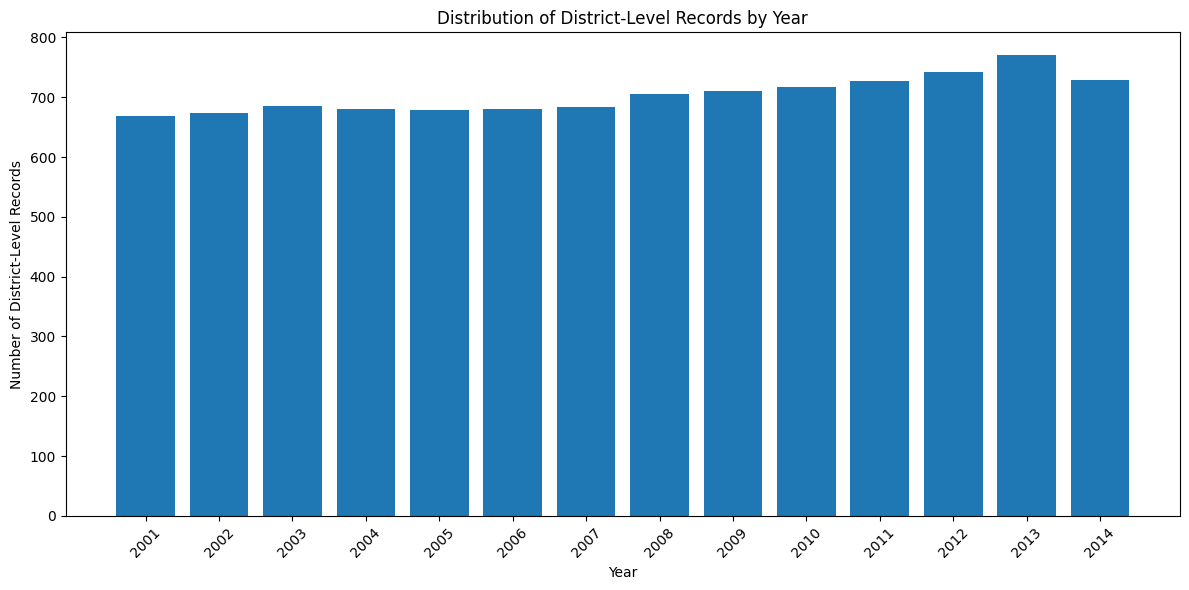

In [9]:
# ============================================================
# CELL 9 — YEAR DISTRIBUTION
# ============================================================

plt.figure(figsize=(12, 6))

plt.bar(
    year_summary["YEAR"].astype(str),
    year_summary["row_count"]
)

plt.title(
    "Distribution of District-Level Records by Year"
)

plt.xlabel("Year")
plt.ylabel("Number of District-Level Records")

plt.xticks(
    rotation=45
)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "eda_year_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [10]:
# ============================================================
# CELL 10 — STATE COVERAGE
# ============================================================

state_summary = (
    df["STATE"]
    .astype(str)
    .str.strip()
    .value_counts()
    .rename_axis("STATE")
    .reset_index(name="row_count")
)

print("=" * 80)
print("STATE COVERAGE")
print("=" * 80)

print(
    f"\nNumber of unique states/UTs: "
    f"{df['STATE'].nunique()}"
)

display(
    state_summary.head(20)
)

state_summary.to_csv(
    TABLES_DIR / "eda_state_summary.csv",
    index=False,
    encoding="utf-8-sig"
)

STATE COVERAGE

Number of unique states/UTs: 72


,STATE,row_count
0,UTTAR PRADESH,867
1,MADHYA PRADESH,617
2,BIHAR,528
3,MAHARASHTRA,456
4,ODISHA,418
5,RAJASTHAN,408
6,ASSAM,339
7,KARNATAKA,337
8,TAMIL NADU,335
9,GUJARAT,324


In [11]:
# ============================================================
# CELL 11 — DISTRICT/UNIT COVERAGE
# ============================================================

unit_summary = (
    df["UNIT_NAME"]
    .astype(str)
    .str.strip()
    .value_counts()
    .rename_axis("UNIT_NAME")
    .reset_index(name="row_count")
)

print("=" * 80)
print("DISTRICT / UNIT COVERAGE")
print("=" * 80)

print(
    f"\nUnique district/unit names: "
    f"{df['UNIT_NAME'].nunique():,}"
)

print("\nTop 30 units by number of records:")

display(
    unit_summary.head(30)
)

unit_summary.to_csv(
    TABLES_DIR / "eda_unit_summary.csv",
    index=False,
    encoding="utf-8-sig"
)

DISTRICT / UNIT COVERAGE

Unique district/unit names: 1,490

Top 30 units by number of records:


,UNIT_NAME,row_count
0,NORTH,53
1,SOUTH,53
2,WEST,51
3,G.R.P.,49
4,EAST,38
5,ZZ TOTAL,35
6,BILASPUR,26
7,HAMIRPUR,26
8,BALRAMPUR,26
9,NEW DELHI,25


In [12]:
# ============================================================
# CELL 12 — MISSING VALUE ANALYSIS
# ============================================================

missing_summary = pd.DataFrame({
    "column": df.columns,
    "missing_count": [
        int(df[col].isna().sum())
        for col in df.columns
    ]
})

missing_summary["missing_pct"] = (
    100 *
    missing_summary["missing_count"] /
    len(df)
).round(2)

missing_summary["non_missing_count"] = (
    len(df) -
    missing_summary["missing_count"]
)

missing_summary = (
    missing_summary
    .sort_values(
        "missing_pct",
        ascending=False
    )
    .reset_index(drop=True)
)

print("=" * 80)
print("MISSING VALUE ANALYSIS")
print("=" * 80)

print(
    f"\nColumns with missing values: "
    f"{(missing_summary['missing_count'] > 0).sum():,}"
)

print(
    f"Columns with no missing values: "
    f"{(missing_summary['missing_count'] == 0).sum():,}"
)

print("\nTop 30 columns by missing percentage:")

display(
    missing_summary.head(30)
)

missing_summary.to_csv(
    TABLES_DIR / "eda_missing_value_summary.csv",
    index=False,
    encoding="utf-8-sig"
)

MISSING VALUE ANALYSIS

Columns with missing values: 323
Columns with no missing values: 8

Top 30 columns by missing percentage:


,column,missing_count,missing_pct,non_missing_count
0,SC_TOTAL_CRIMES_AGAINST_SCS,9128,92.61,728
1,ST_POA_OTHER_DACOITY,9128,92.61,728
2,ST_POA_ATTEMPT_TO_ACID_ATTACK,9128,92.61,728
3,ST_POA_ACID_ATTACK,9128,92.61,728
4,ST_POA_HURT,9128,92.61,728
5,ST_POA_GRIEVOUS_HURT,9128,92.61,728
6,ST_POA_ARSON,9128,92.61,728
7,ST_POA_ROBBERY,9128,92.61,728
8,ST_POA_DACOITY_WITH_MURDER,9128,92.61,728
9,ST_POA_OTHER_IPC_CRIMES,9128,92.61,728


,missing_range,feature_count
0,0%,8
1,0–1%,0
2,1–10%,47
3,10–25%,22
4,25–50%,0
5,50–75%,0
6,75–90%,0
7,90–100%,254


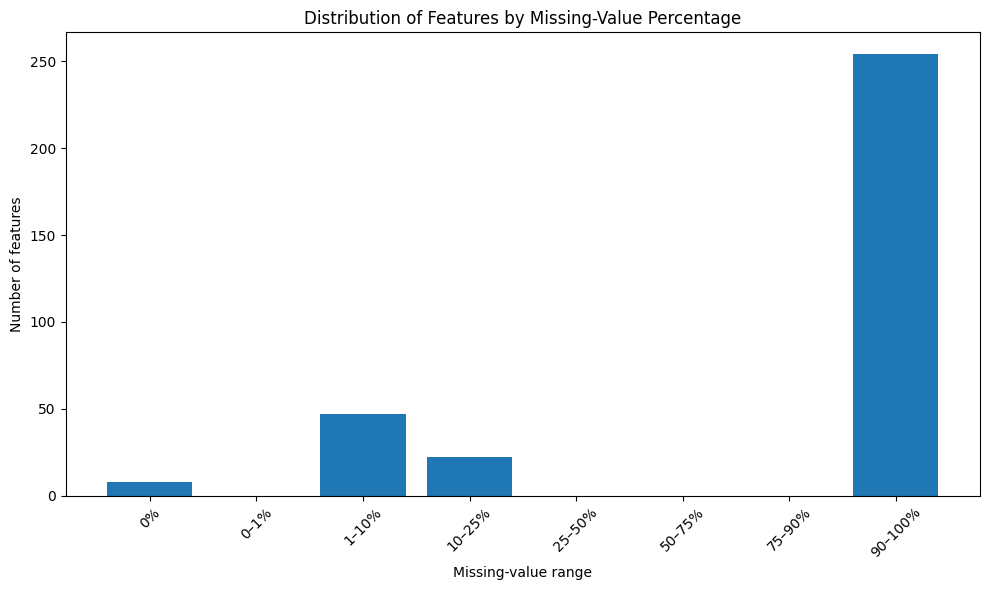

In [13]:
# ============================================================
# CELL 13 — MISSINGNESS DISTRIBUTION
# ============================================================

missing_bins = pd.cut(
    missing_summary["missing_pct"],
    bins=[
        -0.01,
        0,
        1,
        10,
        25,
        50,
        75,
        90,
        100
    ],
    labels=[
        "0%",
        "0–1%",
        "1–10%",
        "10–25%",
        "25–50%",
        "50–75%",
        "75–90%",
        "90–100%"
    ]
)

missing_distribution = (
    missing_bins
    .value_counts()
    .sort_index()
    .rename_axis("missing_range")
    .reset_index(name="feature_count")
)

display(
    missing_distribution
)

plt.figure(figsize=(10, 6))

plt.bar(
    missing_distribution["missing_range"].astype(str),
    missing_distribution["feature_count"]
)

plt.title(
    "Distribution of Features by Missing-Value Percentage"
)

plt.xlabel("Missing-value range")
plt.ylabel("Number of features")

plt.xticks(
    rotation=45
)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "eda_missingness_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [14]:
# ============================================================
# CELL 14 — CRIME-FAMILY AVAILABILITY
# ============================================================

availability_columns = [
    col
    for col in df.columns
    if col.endswith("_AVAILABLE")
]

print("=" * 80)
print("CRIME-FAMILY AVAILABILITY")
print("=" * 80)

print(
    f"\nAvailability indicator columns: "
    f"{len(availability_columns)}"
)

availability_summary = []

for col in availability_columns:

    family = col.replace(
        "_AVAILABLE",
        ""
    )

    available_count = int(
        df[col].eq(True).sum()
    )

    unavailable_count = int(
        df[col].eq(False).sum()
    )

    availability_summary.append({

        "crime_group":
            family,

        "available_rows":
            available_count,

        "unavailable_rows":
            unavailable_count,

        "availability_pct":
            round(
                100 *
                available_count /
                len(df),
                2
            )
    })

availability_summary = pd.DataFrame(
    availability_summary
)

display(
    availability_summary
)

availability_summary.to_csv(
    TABLES_DIR /
    "eda_crime_family_availability.csv",
    index=False,
    encoding="utf-8-sig"
)

CRIME-FAMILY AVAILABILITY

Availability indicator columns: 5


,crime_group,available_rows,unavailable_rows,availability_pct
0,IPC,9631,225,97.72
1,SC,9581,275,97.21
2,ST,9616,240,97.56
3,CHILDREN,8864,992,89.94
4,WOMEN,9630,226,97.71


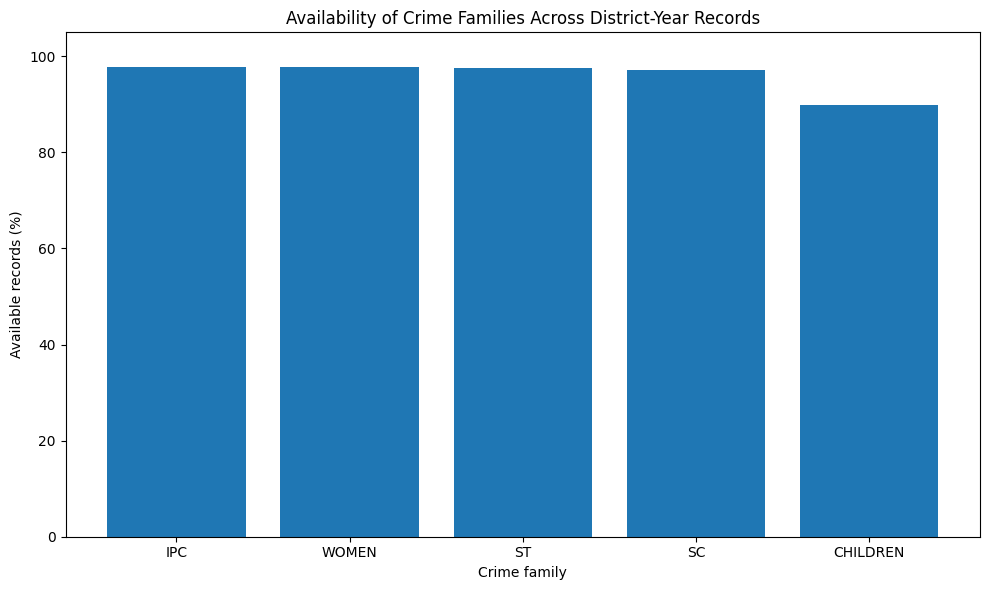

In [15]:
# ============================================================
# CELL 15 — CRIME-FAMILY AVAILABILITY PLOT
# ============================================================

plot_data = availability_summary.sort_values(
    "availability_pct",
    ascending=False
)

plt.figure(figsize=(10, 6))

plt.bar(
    plot_data["crime_group"],
    plot_data["availability_pct"]
)

plt.title(
    "Availability of Crime Families Across District-Year Records"
)

plt.xlabel("Crime family")
plt.ylabel("Available records (%)")

plt.ylim(0, 105)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR /
    "eda_crime_family_availability.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [16]:
# ============================================================
# CELL 16 — NUMERIC FEATURE INVENTORY
# ============================================================

numeric_columns = (
    df
    .select_dtypes(
        include=np.number
    )
    .columns
    .tolist()
)

numeric_crime_columns = [
    col
    for col in numeric_columns
    if col not in ["YEAR"]
]

print("=" * 80)
print("NUMERIC FEATURE INVENTORY")
print("=" * 80)

print(
    f"\nNumeric columns including YEAR : "
    f"{len(numeric_columns)}"
)

print(
    f"Numeric crime-related columns : "
    f"{len(numeric_crime_columns)}"
)

print("\nFirst 50 numeric crime-related columns:")

print(
    numeric_crime_columns[:50]
)

NUMERIC FEATURE INVENTORY

Numeric columns including YEAR : 324
Numeric crime-related columns : 323

First 50 numeric crime-related columns:
['IPC_MURDER', 'IPC_ATTEMPT_TO_MURDER', 'IPC_RAPE', 'IPC_OTHER_RAPE', 'IPC_KIDNAPPING_AND_ABDUCTION_OF_WOMEN_AND_GIRLS', 'IPC_KIDNAPPING_AND_ABDUCTION_OF_OTHERS', 'IPC_DACOITY', 'IPC_PREPARATION_AND_ASSEMBLY_FOR_DACOITY', 'IPC_ROBBERY', 'IPC_BURGLARY', 'IPC_THEFT', 'IPC_OTHER_THEFT', 'IPC_RIOTS', 'IPC_CHEATING', 'IPC_COUNTERFIETING', 'IPC_ARSON', 'IPC_HURT_GREVIOUS_HURT', 'IPC_INSULT_TO_MODESTY_OF_WOMEN', 'IPC_IMPORTATION_OF_GIRLS_FROM_FOREIGN_COUNTRIES', 'IPC_TOTAL_IPC_CRIMES', 'IPC_ATTEMPT_TO_COMMIT_MURDER', 'IPC_ATTEMPT_TO_COMMIT_CULPABLE_HOMICIDE', 'IPC_CUSTODIAL_GANG_RAPE', 'IPC_CUSTODIAL_OTHER_RAPE', 'IPC_RAPE_OTHER_THAN_CUSTODIAL', 'IPC_RAPE_GANG_RAPE', 'IPC_RAPE_OTHERS', 'IPC_ATTEMPT_TO_COMMIT_RAPE', 'IPC_KIDNAPPING_ABDUCTION_TOTAL', 'IPC_KIDNAPPING_ABDUCTION_IN_ORDER_TO_MURDER', 'IPC_KIDNAPPING_FOR_RANSOM', 'IPC_KIDNAPPING_ABDUCTION_OF_WO

In [17]:
# ============================================================
# CELL 17 — NUMERICAL DESCRIPTIVE STATISTICS
# ============================================================

numeric_description = (
    df[
        numeric_crime_columns
    ]
    .describe(
        percentiles=[
            0.01,
            0.25,
            0.50,
            0.75,
            0.95,
            0.99
        ]
    )
    .T
)

numeric_description[
    "missing_count"
] = (
    df[
        numeric_crime_columns
    ]
    .isna()
    .sum()
)

numeric_description[
    "missing_pct"
] = (
    100 *
    numeric_description[
        "missing_count"
    ] /
    len(df)
).round(2)

print("=" * 80)
print("NUMERICAL FEATURE DESCRIPTIVE STATISTICS")
print("=" * 80)

display(
    numeric_description
)

numeric_description.to_csv(
    TABLES_DIR /
    "eda_numeric_descriptive_statistics.csv",
    encoding="utf-8-sig"
)

NUMERICAL FEATURE DESCRIPTIVE STATISTICS


,count,mean,std,min,1%,25%,50%,75%,95%,99%,max,missing_count,missing_pct
IPC_MURDER,9631.0,49.874053,99.740999,0.0,0.0,17.0,36.0,62.0,128.0,220.70,5047.0,225,2.28
IPC_ATTEMPT_TO_MURDER,8902.0,45.579645,115.875548,0.0,0.0,10.0,27.0,55.0,135.0,279.99,5259.0,954,9.68
IPC_RAPE,9631.0,34.782681,95.208837,0.0,0.0,8.0,21.0,42.0,93.0,190.00,4335.0,225,2.28
IPC_OTHER_RAPE,8902.0,33.559762,97.610038,0.0,0.0,8.0,20.0,40.0,88.0,178.00,4335.0,954,9.68
IPC_KIDNAPPING_AND_ABDUCTION_OF_WOMEN_AND_GIRLS,8902.0,41.269939,168.670695,0.0,0.0,6.0,18.0,43.0,124.0,285.00,9737.0,954,9.68
...,...,...,...,...,...,...,...,...,...,...,...,...,...
IPC_CULPABLE_HOMICIDE_NOT_AMOUNTING_TO_MURDER,9631.0,5.584882,17.443522,0.0,0.0,0.0,2.0,6.0,25.0,46.00,1268.0,225,2.28
IPC_CUSTODIAL_RAPE,9631.0,0.023466,0.529376,0.0,0.0,0.0,0.0,0.0,0.0,0.00,28.0,225,2.28
IPC_DOWRY_DEATHS,9631.0,11.784965,33.419427,0.0,0.0,0.0,5.0,16.0,41.0,70.70,2335.0,225,2.28
IPC_KIDNAPPING_ABDUCTION,9631.0,53.480635,209.559504,0.0,0.0,8.0,24.0,55.0,157.0,386.90,11183.0,225,2.28


In [18]:
# ============================================================
# CELL 18 — TOTAL CRIME FEATURES
# ============================================================

total_crime_columns = [
    col
    for col in df.columns
    if (
        "TOTAL" in col.upper()
        and col not in availability_columns
    )
]

print("=" * 80)
print("TOTAL CRIME FEATURES")
print("=" * 80)

print(
    f"\nTotal-related columns found: "
    f"{len(total_crime_columns)}"
)

for col in total_crime_columns:
    print(
        f"  {col}"
    )

TOTAL CRIME FEATURES

Total-related columns found: 19
  IPC_TOTAL_IPC_CRIMES
  IPC_KIDNAPPING_ABDUCTION_TOTAL
  IPC_TOTAL_COGNIZABLE_IPC_CRIMES
  SC_POA_KIDNAPPING_ABDUCTION_GRANDTOTAL
  SC_POA_KIDNAPING_ABDUCTION_TOTAL
  SC_TOTAL_OF_SC_ST_PREVENTION_OF_ATROCITIES_ACT_1989
  SC_TOTAL_IPC_CRIMES_AGAINST_SCS
  SC_TOTAL_CRIMES_AGAINST_SCS
  ST_POA_KIDNAPPING_ABDUCTION_GRANDTOTAL
  ST_POA_KIDNAPING_ABDUCTION_TOTAL
  ST_TOTAL_OF_SC_ST_PREVENTION_OF_ATROCITIES_ACT_1989
  ST_TOTAL_IPC_CRIMES_AGAINST_STS
  ST_TOTAL_CRIMES_AGAINST_STS
  CHILDREN_TOTAL
  WOMEN_KIDNAPPING_ABDUCTION_TOTAL
  WOMEN_ASSAULT_ON_WOMEN_WITH_INTENT_TO_OUTRAGE_HER_MODESTY_TOTAL
  WOMEN_INSULT_TO_THE_MODESTY_OF_WOMEN_TOTAL
  WOMEN_DACOITY_TOTAL
  WOMEN_TOTAL_CRIMES_AGAINST_WOMEN


In [19]:
# ============================================================
# CELL 19 — TOTAL CRIME FEATURE SUMMARY
# ============================================================

total_summary_records = []

for col in total_crime_columns:

    series = df[col]

    total_summary_records.append({

        "feature":
            col,

        "non_missing":
            int(series.notna().sum()),

        "missing":
            int(series.isna().sum()),

        "missing_pct":
            round(
                100 * series.isna().mean(),
                2
            ),

        "mean":
            series.mean(),

        "median":
            series.median(),

        "max":
            series.max(),

        "sum":
            series.sum()
    })

total_crime_summary = pd.DataFrame(
    total_summary_records
)

display(
    total_crime_summary
)

total_crime_summary.to_csv(
    TABLES_DIR /
    "eda_total_crime_feature_summary.csv",
    index=False,
    encoding="utf-8-sig"
)

,feature,non_missing,missing,missing_pct,mean,median,max,sum
0,IPC_TOTAL_IPC_CRIMES,8902,954,9.68,3090.330825,1947.5,234385.0,27510125.0
1,IPC_KIDNAPPING_ABDUCTION_TOTAL,729,9127,92.60,100.912209,61.0,1198.0,73565.0
2,IPC_TOTAL_COGNIZABLE_IPC_CRIMES,729,9127,92.60,3484.449931,2469.0,40361.0,2540164.0
3,SC_POA_KIDNAPPING_ABDUCTION_GRANDTOTAL,728,9128,92.61,1.000000,0.0,19.0,728.0
4,SC_POA_KIDNAPING_ABDUCTION_TOTAL,728,9128,92.61,0.226648,0.0,16.0,165.0
5,SC_TOTAL_OF_SC_ST_PREVENTION_OF_ATROCITIES_ACT_1989,728,9128,92.61,52.549451,21.0,770.0,38256.0
6,SC_TOTAL_IPC_CRIMES_AGAINST_SCS,728,9128,92.61,7.471154,0.0,544.0,5439.0
7,SC_TOTAL_CRIMES_AGAINST_SCS,728,9128,92.61,60.362637,24.0,876.0,43944.0
8,ST_POA_KIDNAPPING_ABDUCTION_GRANDTOTAL,728,9128,92.61,0.222527,0.0,15.0,162.0
9,ST_POA_KIDNAPING_ABDUCTION_TOTAL,728,9128,92.61,0.050824,0.0,6.0,37.0


In [20]:
# ============================================================
# CELL 20 — TOP CRIME FEATURES BY OBSERVED SUM
# ============================================================

feature_sum_records = []

for col in numeric_crime_columns:

    series = pd.to_numeric(
        df[col],
        errors="coerce"
    )

    feature_sum_records.append({

        "feature":
            col,

        "observed_sum":
            series.sum(),

        "mean":
            series.mean(),

        "median":
            series.median(),

        "non_missing":
            series.notna().sum(),

        "missing_pct":
            100 * series.isna().mean()
    })

feature_sum_summary = pd.DataFrame(
    feature_sum_records
)

feature_sum_summary = (
    feature_sum_summary
    .sort_values(
        "observed_sum",
        ascending=False
    )
    .reset_index(drop=True)
)

print("=" * 80)
print("TOP CRIME FEATURES BY OBSERVED SUM")
print("=" * 80)

display(
    feature_sum_summary.head(30)
)

feature_sum_summary.to_csv(
    TABLES_DIR /
    "eda_top_crime_features_by_sum.csv",
    index=False,
    encoding="utf-8-sig"
)

TOP CRIME FEATURES BY OBSERVED SUM


,feature,observed_sum,mean,median,non_missing,missing_pct
0,IPC_TOTAL_IPC_CRIMES,27510125.0,3090.330825,1947.5,8902,9.679383
1,IPC_OTHER_IPC_CRIMES,12066571.0,1252.888693,697.0,9631,2.282873
2,IPC_THEFT,4543734.0,471.782162,201.0,9631,2.282873
3,IPC_HURT_GREVIOUS_HURT,3702045.0,415.866659,182.0,8902,9.679383
4,IPC_TOTAL_COGNIZABLE_IPC_CRIMES,2540164.0,3484.449931,2469.0,729,92.603490
5,IPC_OTHER_THEFT,2538092.0,285.114806,139.0,8902,9.679383
6,IPC_AUTO_THEFT,1789219.0,185.777074,46.0,9631,2.282873
7,IPC_BURGLARY,1247259.0,140.109975,78.0,8902,9.679383
8,IPC_CAUSING_DEATH_BY_NEGLIGENCE,1218156.0,126.482816,68.0,9631,2.282873
9,IPC_CRUELTY_BY_HUSBAND_OR_HIS_RELATIVES,1156619.0,120.093344,47.0,9631,2.282873


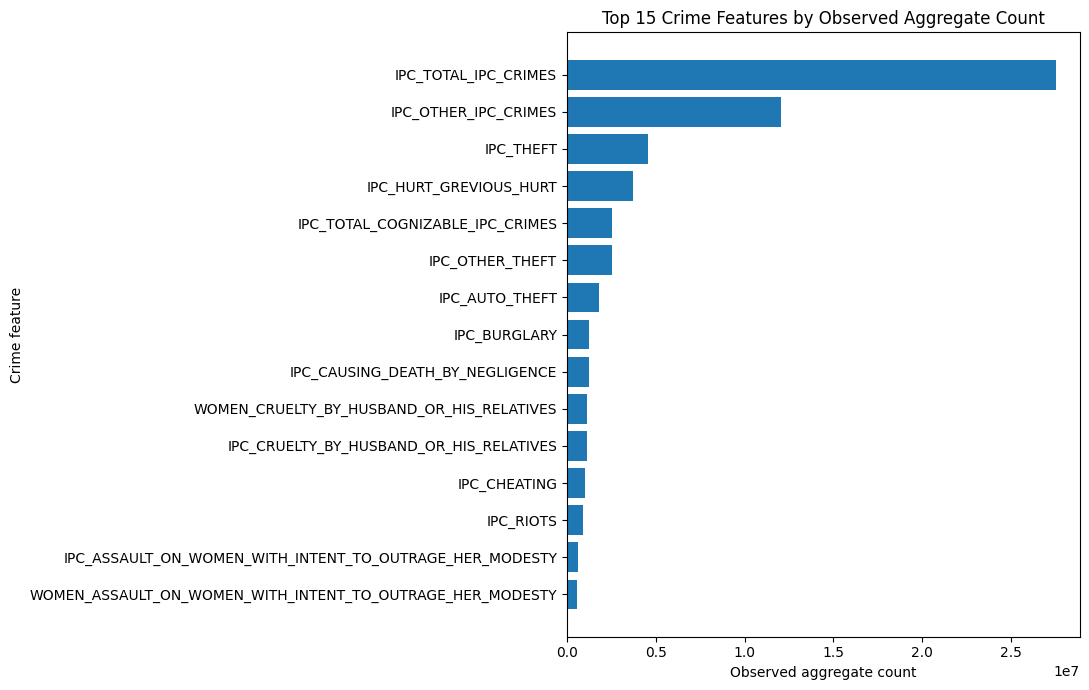

In [21]:
# ============================================================
# CELL 21 — TOP 15 CRIME FEATURES
# ============================================================

top_features = (
    feature_sum_summary
    .head(15)
    .sort_values(
        "observed_sum"
    )
)

plt.figure(figsize=(11, 7))

plt.barh(
    top_features["feature"],
    top_features["observed_sum"]
)

plt.title(
    "Top 15 Crime Features by Observed Aggregate Count"
)

plt.xlabel(
    "Observed aggregate count"
)

plt.ylabel(
    "Crime feature"
)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR /
    "eda_top_15_crime_features.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [22]:
# ============================================================
# CELL 22 — YEARLY TRENDS FOR TOP CRIME FEATURES
# ============================================================

top_trend_features = (
    feature_sum_summary
    .head(8)["feature"]
    .tolist()
)

yearly_feature_trends = (
    df
    .groupby("YEAR")[
        top_trend_features
    ]
    .sum(
        min_count=1
    )
    .reset_index()
)

print("=" * 80)
print("YEARLY TRENDS — TOP CRIME FEATURES")
print("=" * 80)

display(
    yearly_feature_trends
)

yearly_feature_trends.to_csv(
    TABLES_DIR /
    "eda_yearly_top_crime_feature_trends.csv",
    index=False,
    encoding="utf-8-sig"
)

YEARLY TRENDS — TOP CRIME FEATURES


,YEAR,IPC_TOTAL_IPC_CRIMES,IPC_OTHER_IPC_CRIMES,IPC_THEFT,IPC_HURT_GREVIOUS_HURT,IPC_TOTAL_COGNIZABLE_IPC_CRIMES,IPC_OTHER_THEFT,IPC_AUTO_THEFT,IPC_BURGLARY
0,2001,1712275.0,683312.0,256074.0,251139.0,NaN,188454.0,67620.0,97842.0
1,2002,1713728.0,707546.0,246297.0,246431.0,NaN,176508.0,69789.0,92282.0
2,2003,1621660.0,666188.0,239824.0,236239.0,NaN,168419.0,71405.0,87034.0
3,2004,1739621.0,704274.0,271188.0,251718.0,NaN,187187.0,84001.0,87253.0
4,2005,1727431.0,705811.0,270331.0,242718.0,NaN,181677.0,88654.0,85443.0
5,2006,1767687.0,734692.0,268351.0,239940.0,NaN,175266.0,93085.0,86017.0
6,2007,1866714.0,775905.0,277969.0,247426.0,NaN,176939.0,101030.0,86103.0
7,2008,1956158.0,796309.0,309580.0,257800.0,NaN,188184.0,121396.0,87704.0
8,2009,1983365.0,800688.0,318606.0,254426.0,NaN,176241.0,142365.0,85374.0
9,2010,2065042.0,848362.0,325063.0,260600.0,NaN,173521.0,151542.0,82783.0


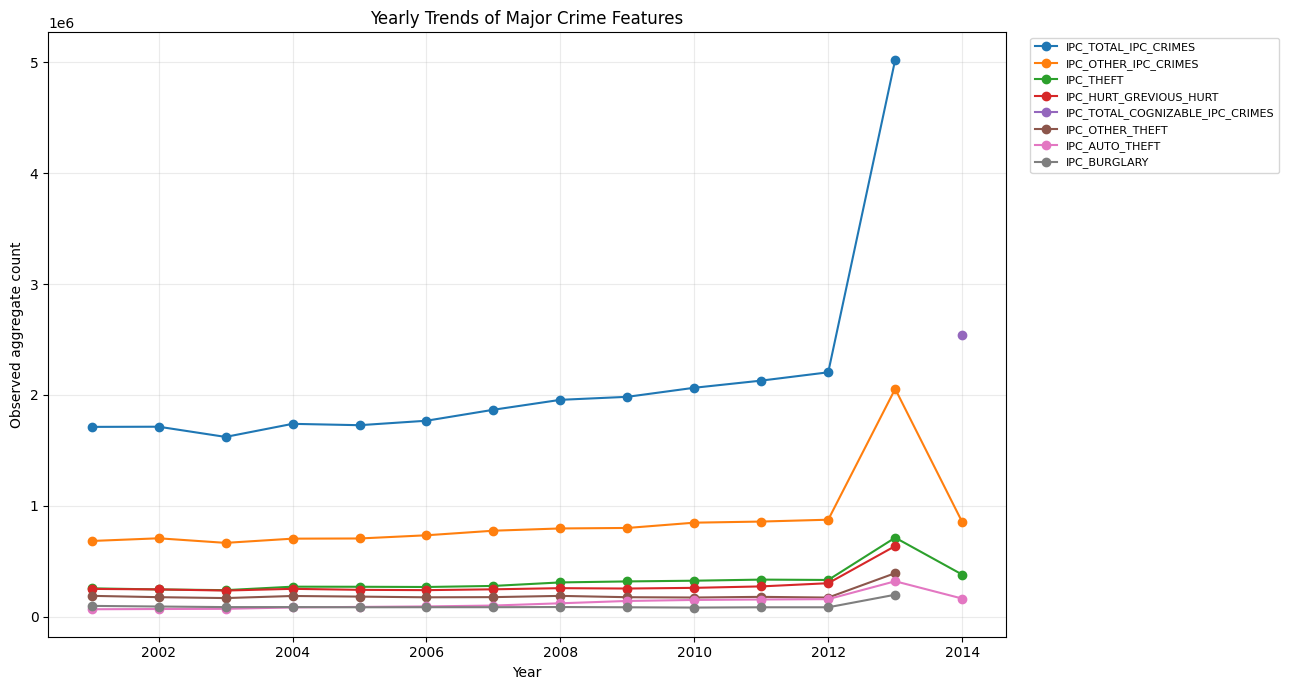

In [23]:
# ============================================================
# CELL 23 — YEARLY CRIME TRENDS PLOT
# ============================================================

plt.figure(figsize=(13, 7))

for feature in top_trend_features:

    plt.plot(
        yearly_feature_trends["YEAR"],
        yearly_feature_trends[feature],
        marker="o",
        label=feature
    )

plt.title(
    "Yearly Trends of Major Crime Features"
)

plt.xlabel("Year")
plt.ylabel("Observed aggregate count")

plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    fontsize=8
)

plt.grid(
    alpha=0.25
)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR /
    "eda_yearly_major_crime_trends.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [24]:
# ============================================================
# CELL 24 — STATE-WISE MAJOR CRIME AGGREGATION
# ============================================================

state_crime_summary = (
    df
    .groupby("STATE")[
        top_trend_features
    ]
    .sum(
        min_count=1
    )
    .reset_index()
)

print("=" * 80)
print("STATE-WISE MAJOR CRIME AGGREGATION")
print("=" * 80)

display(
    state_crime_summary.head(20)
)

state_crime_summary.to_csv(
    TABLES_DIR /
    "eda_state_wise_major_crime_summary.csv",
    index=False,
    encoding="utf-8-sig"
)

STATE-WISE MAJOR CRIME AGGREGATION


,STATE,IPC_TOTAL_IPC_CRIMES,IPC_OTHER_IPC_CRIMES,IPC_THEFT,IPC_HURT_GREVIOUS_HURT,IPC_TOTAL_COGNIZABLE_IPC_CRIMES,IPC_OTHER_THEFT,IPC_AUTO_THEFT,IPC_BURGLARY
0,A & N ISLANDS,9102.0,4443.0,1124.0,1105.0,NaN,1039.0,85.0,892.0
1,A&N Islands,1224.0,787.0,119.0,110.0,746.0,70.0,8.0,84.0
2,ANDHRA PRADESH,1707750.0,434863.0,213655.0,466100.0,NaN,167265.0,46390.0,79619.0
3,ARUNACHAL PRADESH,27354.0,7326.0,5147.0,5091.0,NaN,4082.0,1065.0,2756.0
4,ASSAM,520834.0,154729.0,66872.0,62742.0,NaN,58575.0,8297.0,28051.0
5,Andhra Pradesh,395320.0,128180.0,62850.0,111605.0,92538.0,38119.0,17946.0,17950.0
6,Arunachal Pradesh,5443.0,2035.0,1330.0,974.0,2086.0,706.0,347.0,387.0
7,Assam,162210.0,84323.0,28377.0,16013.0,82121.0,12359.0,8401.0,7754.0
8,BIHAR,1346293.0,538591.0,153372.0,189266.0,NaN,119151.0,34221.0,40293.0
9,Bihar,334910.0,195868.0,64238.0,71350.0,175172.0,28516.0,23001.0,8370.0


In [25]:
# ============================================================
# CELL 25 — STATE-WISE AGGREGATE OF MAJOR CRIME FEATURES
# ============================================================

state_crime_summary["major_crime_aggregate"] = (
    state_crime_summary[
        top_trend_features
    ]
    .sum(
        axis=1,
        skipna=True
    )
)

state_major_crime = (
    state_crime_summary[
        [
            "STATE",
            "major_crime_aggregate"
        ]
    ]
    .sort_values(
        "major_crime_aggregate",
        ascending=False
    )
    .reset_index(drop=True)
)

print("=" * 80)
print("STATE-WISE AGGREGATE — MAJOR CRIME FEATURES")
print("=" * 80)

display(
    state_major_crime.head(20)
)

state_major_crime.to_csv(
    TABLES_DIR /
    "eda_state_major_crime_aggregate.csv",
    index=False,
    encoding="utf-8-sig"
)

STATE-WISE AGGREGATE — MAJOR CRIME FEATURES


,STATE,major_crime_aggregate
0,MADHYA PRADESH,4687995.0
1,MAHARASHTRA,3794564.0
2,UTTAR PRADESH,3314454.0
3,RAJASTHAN,3184315.0
4,ANDHRA PRADESH,3115642.0
5,TAMIL NADU,2893172.0
6,DELHI UT,2758976.0
7,KARNATAKA,2608056.0
8,GUJARAT,2457178.0
9,BIHAR,2421187.0


In [26]:
# ============================================================
# CELL 26 — CRIME FAMILY FEATURE COUNTS
# ============================================================

crime_families = [
    "IPC",
    "SC",
    "ST",
    "CHILDREN",
    "WOMEN"
]

family_feature_records = []

for family in crime_families:

    family_prefix = family + "_"

    family_columns = [
        col
        for col in df.columns
        if col.startswith(family_prefix)
        and not col.endswith("_AVAILABLE")
    ]

    family_feature_records.append({

        "crime_group":
            family,

        "feature_count":
            len(family_columns),

        "numeric_feature_count":
            sum(
                col in numeric_crime_columns
                for col in family_columns
            )
    })

family_feature_summary = pd.DataFrame(
    family_feature_records
)

print("=" * 80)
print("CRIME FAMILY FEATURE COUNTS")
print("=" * 80)

display(
    family_feature_summary
)

family_feature_summary.to_csv(
    TABLES_DIR /
    "eda_crime_family_feature_counts.csv",
    index=False,
    encoding="utf-8-sig"
)

CRIME FAMILY FEATURE COUNTS


,crime_group,feature_count,numeric_feature_count
0,IPC,100,100
1,SC,73,73
2,ST,73,73
3,CHILDREN,14,14
4,WOMEN,63,63


In [27]:
# ============================================================
# CELL 27 — TOP FEATURES BY MEAN OBSERVED VALUE
# ============================================================

feature_mean_summary = []

for col in numeric_crime_columns:

    series = pd.to_numeric(
        df[col],
        errors="coerce"
    )

    non_missing = series.dropna()

    if len(non_missing) == 0:
        continue

    feature_mean_summary.append({

        "feature":
            col,

        "mean_observed":
            non_missing.mean(),

        "median_observed":
            non_missing.median(),

        "max_observed":
            non_missing.max(),

        "non_missing":
            len(non_missing),

        "missing_pct":
            100 * series.isna().mean()
    })

feature_mean_summary = pd.DataFrame(
    feature_mean_summary
)

feature_mean_summary = (
    feature_mean_summary
    .sort_values(
        "mean_observed",
        ascending=False
    )
    .reset_index(drop=True)
)

print("=" * 80)
print("TOP FEATURES BY MEAN OBSERVED VALUE")
print("=" * 80)

display(
    feature_mean_summary.head(30)
)

feature_mean_summary.to_csv(
    TABLES_DIR /
    "eda_features_by_mean_observed.csv",
    index=False,
    encoding="utf-8-sig"
)

TOP FEATURES BY MEAN OBSERVED VALUE


,feature,mean_observed,median_observed,max_observed,non_missing,missing_pct
0,IPC_TOTAL_COGNIZABLE_IPC_CRIMES,3484.449931,2469.0,40361.0,729,92.603490
1,IPC_TOTAL_IPC_CRIMES,3090.330825,1947.5,234385.0,8902,9.679383
2,IPC_OTHER_IPC_CRIMES,1252.888693,697.0,127850.0,9631,2.282873
3,WOMEN_TOTAL_CRIMES_AGAINST_WOMEN,575.152473,382.0,8244.0,728,92.613636
4,IPC_THEFT,471.782162,201.0,52670.0,9631,2.282873
5,IPC_INCIDENCE_OF_RASH_DRIVING,464.041152,177.0,13431.0,729,92.603490
6,IPC_HURT_GREVIOUS_HURT,415.866659,182.0,60488.0,8902,9.679383
7,IPC_OTHER_THEFTS,296.876543,135.0,7375.0,729,92.603490
8,IPC_OTHER_THEFT,285.114806,139.0,34276.0,8902,9.679383
9,IPC_AUTO_THEFT,185.777074,46.0,24948.0,9631,2.282873


Features selected for distribution analysis:
  IPC_TOTAL_IPC_CRIMES
  IPC_OTHER_IPC_CRIMES
  IPC_THEFT
  IPC_HURT_GREVIOUS_HURT
  IPC_TOTAL_COGNIZABLE_IPC_CRIMES
  IPC_OTHER_THEFT


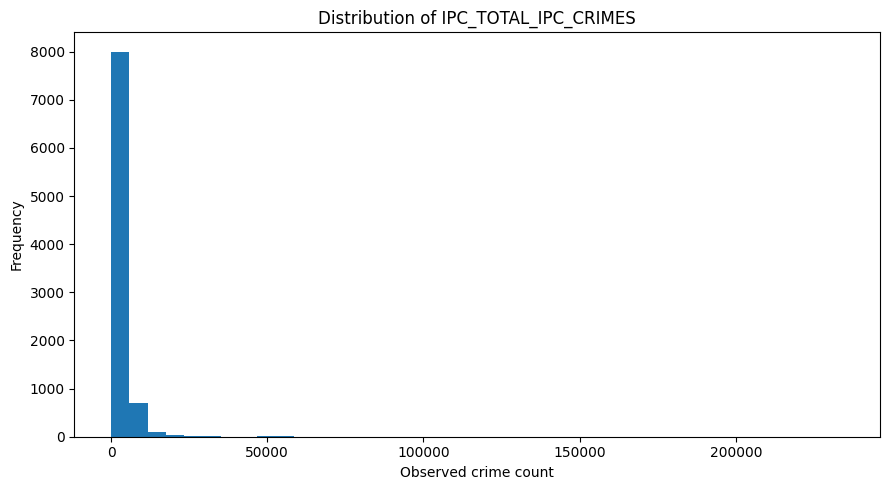

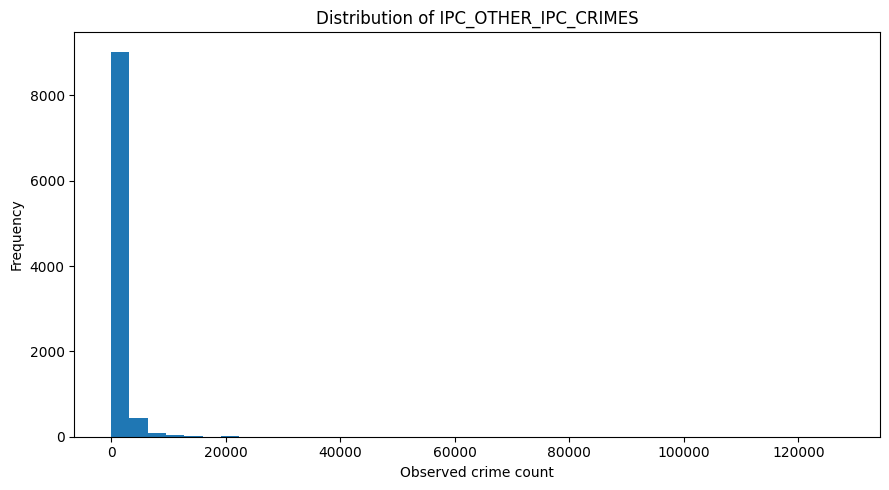

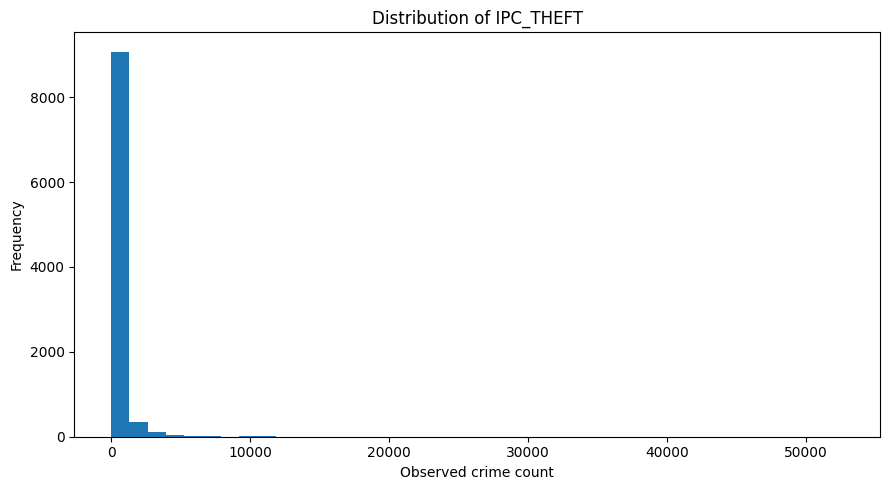

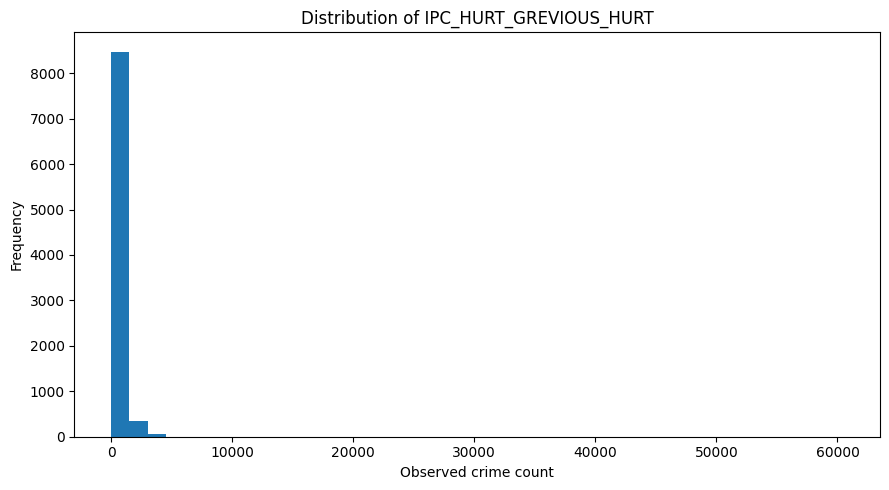

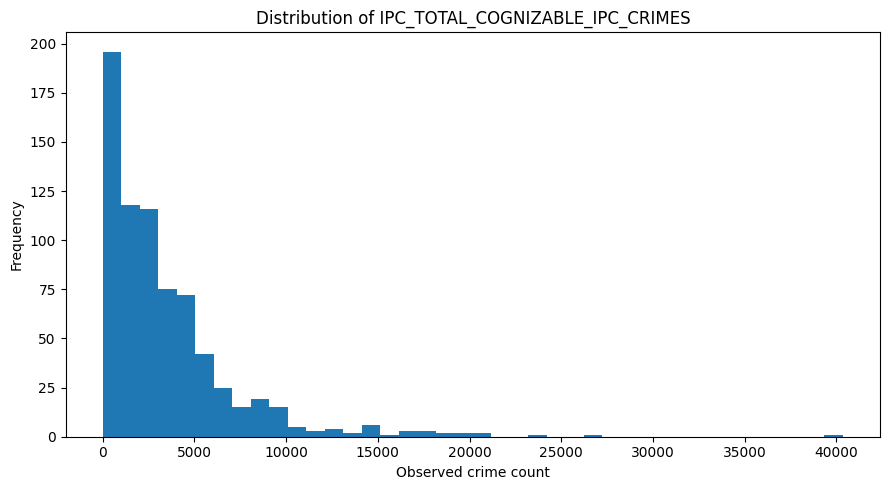

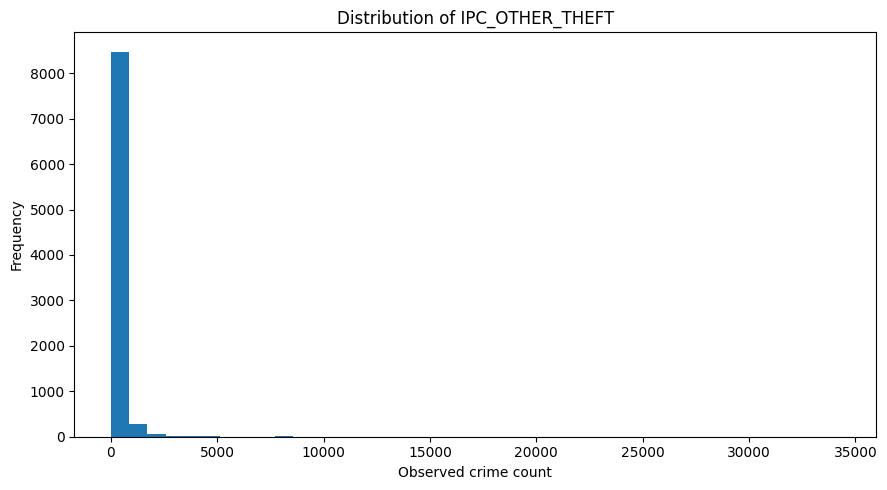

In [28]:
# ============================================================
# CELL 28 — DISTRIBUTION OF MAJOR CRIME FEATURES
# ============================================================

distribution_features = (
    feature_sum_summary
    .head(6)["feature"]
    .tolist()
)

print(
    "Features selected for distribution analysis:"
)

for feature in distribution_features:
    print(
        f"  {feature}"
    )

for feature in distribution_features:

    values = pd.to_numeric(
        df[feature],
        errors="coerce"
    ).dropna()

    if values.empty:
        continue

    plt.figure(figsize=(9, 5))

    plt.hist(
        values,
        bins=40
    )

    plt.title(
        f"Distribution of {feature}"
    )

    plt.xlabel(
        "Observed crime count"
    )

    plt.ylabel(
        "Frequency"
    )

    plt.tight_layout()

    safe_name = (
        feature
        .replace("/", "_")
        .replace(" ", "_")
    )

    plt.savefig(
        FIGURES_DIR /
        f"eda_distribution_{safe_name}.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

In [29]:
# ============================================================
# CELL 29 — ZERO-VALUE ANALYSIS
# ============================================================

zero_records = []

for col in numeric_crime_columns:

    series = pd.to_numeric(
        df[col],
        errors="coerce"
    )

    observed = series.dropna()

    if len(observed) == 0:
        continue

    zero_count = int(
        (observed == 0).sum()
    )

    zero_records.append({

        "feature":
            col,

        "observed_count":
            len(observed),

        "zero_count":
            zero_count,

        "zero_pct_observed":
            round(
                100 *
                zero_count /
                len(observed),
                2
            )
    })

zero_summary = pd.DataFrame(
    zero_records
)

zero_summary = (
    zero_summary
    .sort_values(
        "zero_pct_observed",
        ascending=False
    )
    .reset_index(drop=True)
)

print("=" * 80)
print("ZERO-VALUE ANALYSIS")
print("=" * 80)

display(
    zero_summary.head(30)
)

zero_summary.to_csv(
    TABLES_DIR /
    "eda_zero_value_summary.csv",
    index=False,
    encoding="utf-8-sig"
)

ZERO-VALUE ANALYSIS


,feature,observed_count,zero_count,zero_pct_observed
0,SC_POA_DACOITY_WITH_MURDER,728,728,100.00
1,ST_POA_KIDNAPPING_FOR_RANSOM,728,728,100.00
2,ST_IPC_DACOITY_WITH_MURDER,728,728,100.00
3,ST_IPC_DACOITY,728,728,100.00
4,ST_POA_ATTEMPT_TO_ACID_ATTACK,728,728,100.00
5,ST_IPC_VOYEURISM,728,728,100.00
6,ST_IPC_ACID_ATTACK,728,728,100.00
7,ST_POA_DACOITY_WITH_MURDER,728,728,100.00
8,ST_IPC_ATTEMPT_TO_ACID_ATTACK,728,728,100.00
9,SC_IPC_ACID_ATTACK,728,728,100.00


In [30]:
# ============================================================
# CELL 30 — HIGHLY ZERO-DOMINATED FEATURES
# ============================================================

high_zero_features = (
    zero_summary[
        zero_summary["zero_pct_observed"] >= 90
    ]
    .copy()
)

print("=" * 80)
print("HIGHLY ZERO-DOMINATED FEATURES")
print("=" * 80)

print(
    f"\nFeatures with >=90% observed zeros: "
    f"{len(high_zero_features):,}"
)

display(
    high_zero_features.head(50)
)

high_zero_features.to_csv(
    TABLES_DIR /
    "eda_high_zero_features.csv",
    index=False,
    encoding="utf-8-sig"
)

HIGHLY ZERO-DOMINATED FEATURES

Features with >=90% observed zeros: 159


,feature,observed_count,zero_count,zero_pct_observed
0,SC_POA_DACOITY_WITH_MURDER,728,728,100.00
1,ST_POA_KIDNAPPING_FOR_RANSOM,728,728,100.00
2,ST_IPC_DACOITY_WITH_MURDER,728,728,100.00
3,ST_IPC_DACOITY,728,728,100.00
4,ST_POA_ATTEMPT_TO_ACID_ATTACK,728,728,100.00
5,ST_IPC_VOYEURISM,728,728,100.00
6,ST_IPC_ACID_ATTACK,728,728,100.00
7,ST_POA_DACOITY_WITH_MURDER,728,728,100.00
8,ST_IPC_ATTEMPT_TO_ACID_ATTACK,728,728,100.00
9,SC_IPC_ACID_ATTACK,728,728,100.00


In [31]:
# ============================================================
# CELL 31 — FEATURE SELECTION FOR CORRELATION ANALYSIS
# ============================================================

correlation_candidates = []

for col in numeric_crime_columns:

    series = pd.to_numeric(
        df[col],
        errors="coerce"
    )

    non_missing = series.dropna()

    if len(non_missing) < 100:
        continue

    correlation_candidates.append({

        "feature":
            col,

        "non_missing":
            len(non_missing),

        "variance":
            non_missing.var(),

        "mean":
            non_missing.mean()
    })

correlation_candidates = pd.DataFrame(
    correlation_candidates
)

correlation_candidates = (
    correlation_candidates
    .sort_values(
        "variance",
        ascending=False
    )
)

correlation_features = (
    correlation_candidates
    .head(30)["feature"]
    .tolist()
)

print("=" * 80)
print("CORRELATION ANALYSIS FEATURES")
print("=" * 80)

print(
    f"\nFeatures selected: "
    f"{len(correlation_features)}"
)

print(
    correlation_features
)

CORRELATION ANALYSIS FEATURES

Features selected: 30
['IPC_TOTAL_IPC_CRIMES', 'IPC_TOTAL_COGNIZABLE_IPC_CRIMES', 'IPC_OTHER_IPC_CRIMES', 'IPC_THEFT', 'IPC_HURT_GREVIOUS_HURT', 'IPC_INCIDENCE_OF_RASH_DRIVING', 'IPC_OTHER_THEFT', 'IPC_AUTO_THEFT', 'WOMEN_TOTAL_CRIMES_AGAINST_WOMEN', 'IPC_OTHER_THEFTS', 'WOMEN_CRUELTY_BY_HUSBAND_OR_HIS_RELATIVES', 'IPC_CRUELTY_BY_HUSBAND_OR_HIS_RELATIVES', 'IPC_CHEATING', 'IPC_BURGLARY', 'IPC_CAUSING_DEATH_BY_NEGLIGENCE', 'IPC_GRIEVOUS_HURT', 'IPC_HURT', 'IPC_RIOTS', 'IPC_CRIMINAL_TRESPASS_BURGLARY', 'WOMEN_OTHER_IPC_CRIMES', 'WOMEN_ASSAULT_ON_WOMEN_WITH_INTENT_TO_OUTRAGE_HER_MODESTY', 'IPC_ASSAULT_ON_WOMEN_WITH_INTENT_TO_OUTRAGE_HER_MODESTY', 'IPC_KIDNAPPING_ABDUCTION', 'IPC_CRIMINAL_TRESPASS_OR_BURGLARY', 'IPC_KIDNAPPING_AND_ABDUCTION_OF_WOMEN_AND_GIRLS', 'WOMEN_KIDNAPPING_AND_ABDUCTION', 'IPC_DEATHS_DUE_TO_NEGLIGENT_DRIVING_ACT', 'IPC_ROBBERY', 'IPC_RIOTS_OTHERS', 'IPC_KIDNAPPING_ABDUCTION_TOTAL']


In [32]:
# ============================================================
# CELL 32 — CORRELATION MATRIX
# ============================================================

correlation_matrix = (
    df[
        correlation_features
    ]
    .corr(
        method="pearson",
        min_periods=50
    )
)

print("=" * 80)
print("CORRELATION MATRIX")
print("=" * 80)

display(
    correlation_matrix
)

correlation_matrix.to_csv(
    TABLES_DIR /
    "eda_correlation_matrix.csv",
    encoding="utf-8-sig"
)

CORRELATION MATRIX


,IPC_TOTAL_IPC_CRIMES,IPC_TOTAL_COGNIZABLE_IPC_CRIMES,IPC_OTHER_IPC_CRIMES,IPC_THEFT,IPC_HURT_GREVIOUS_HURT,IPC_INCIDENCE_OF_RASH_DRIVING,IPC_OTHER_THEFT,IPC_AUTO_THEFT,WOMEN_TOTAL_CRIMES_AGAINST_WOMEN,IPC_OTHER_THEFTS,WOMEN_CRUELTY_BY_HUSBAND_OR_HIS_RELATIVES,IPC_CRUELTY_BY_HUSBAND_OR_HIS_RELATIVES,IPC_CHEATING,IPC_BURGLARY,IPC_CAUSING_DEATH_BY_NEGLIGENCE,IPC_GRIEVOUS_HURT,IPC_HURT,IPC_RIOTS,IPC_CRIMINAL_TRESPASS_BURGLARY,WOMEN_OTHER_IPC_CRIMES,WOMEN_ASSAULT_ON_WOMEN_WITH_INTENT_TO_OUTRAGE_HER_MODESTY,IPC_ASSAULT_ON_WOMEN_WITH_INTENT_TO_OUTRAGE_HER_MODESTY,IPC_KIDNAPPING_ABDUCTION,IPC_CRIMINAL_TRESPASS_OR_BURGLARY,IPC_KIDNAPPING_AND_ABDUCTION_OF_WOMEN_AND_GIRLS,WOMEN_KIDNAPPING_AND_ABDUCTION,IPC_DEATHS_DUE_TO_NEGLIGENT_DRIVING_ACT,IPC_ROBBERY,IPC_RIOTS_OTHERS,IPC_KIDNAPPING_ABDUCTION_TOTAL
IPC_TOTAL_IPC_CRIMES,1.000000,NaN,0.931767,0.849506,0.841294,NaN,0.840525,0.776083,NaN,NaN,0.809310,0.805571,0.810668,0.857888,0.837243,NaN,NaN,0.701174,NaN,NaN,0.869332,0.863456,0.766289,NaN,0.768756,0.758140,NaN,0.720718,NaN,NaN
IPC_TOTAL_COGNIZABLE_IPC_CRIMES,NaN,1.000000,0.843428,0.745180,NaN,0.584612,NaN,0.698753,0.836975,0.685260,0.610092,0.610318,0.714201,NaN,0.644814,0.383918,0.383117,0.436133,0.761811,0.511947,NaN,0.749295,0.554932,0.710835,NaN,NaN,0.611460,0.612555,0.435406,0.706472
IPC_OTHER_IPC_CRIMES,0.931767,0.843428,1.000000,0.667087,0.711107,0.414985,0.656178,0.625874,0.687421,0.386212,0.683633,0.684654,0.655368,0.709161,0.726633,0.252258,0.251783,0.651744,0.520170,0.425317,0.740463,0.735142,0.642267,0.479976,0.660198,0.651378,0.592547,0.560524,0.442165,0.513098
IPC_THEFT,0.849506,0.745180,0.667087,1.000000,0.628265,0.194493,0.958165,0.945897,0.640556,0.949383,0.682150,0.644332,0.763556,0.842495,0.661712,0.197139,0.196118,0.487570,0.813932,0.498267,0.776129,0.715698,0.777527,0.745689,0.737315,0.714698,0.306764,0.751162,0.159342,0.747720
IPC_HURT_GREVIOUS_HURT,0.841294,NaN,0.711107,0.628265,1.000000,NaN,0.687639,0.500728,NaN,NaN,0.709588,0.708505,0.680469,0.761403,0.750514,NaN,NaN,0.630678,NaN,NaN,0.782202,0.781769,0.511294,NaN,0.521576,0.536224,NaN,0.546708,NaN,NaN
IPC_INCIDENCE_OF_RASH_DRIVING,NaN,0.584612,0.414985,0.194493,NaN,1.000000,NaN,0.189705,0.256701,0.173682,0.154552,0.154831,0.317374,NaN,0.388737,0.017060,0.016861,0.187303,0.293700,0.207429,NaN,0.315832,0.107064,0.264010,NaN,NaN,0.385818,0.165605,0.186750,0.078718
IPC_OTHER_THEFT,0.840525,NaN,0.656178,0.958165,0.687639,NaN,1.000000,0.817704,NaN,NaN,0.695903,0.673670,0.742279,0.847334,0.675612,NaN,NaN,0.546174,NaN,NaN,0.751375,0.724732,0.690689,NaN,0.657067,0.627885,NaN,0.755423,NaN,NaN
IPC_AUTO_THEFT,0.776083,0.698753,0.625874,0.945897,0.500728,0.189705,0.817704,1.000000,0.599110,0.710342,0.613755,0.565980,0.722928,0.754429,0.597700,0.189371,0.188352,0.391638,0.770649,0.500113,0.720999,0.642571,0.797778,0.717834,0.753966,0.742831,0.352733,0.670039,0.168581,0.704579
WOMEN_TOTAL_CRIMES_AGAINST_WOMEN,NaN,0.836975,0.687421,0.640556,NaN,0.256701,NaN,0.599110,1.000000,0.590136,0.754097,0.754097,0.591525,NaN,0.501433,0.493924,0.493070,0.392367,0.685760,0.640709,NaN,0.830295,0.543311,0.650208,NaN,NaN,0.458408,0.605510,0.386615,0.763059
IPC_OTHER_THEFTS,NaN,0.685260,0.386212,0.949383,NaN,0.173682,NaN,0.710342,0.590136,1.000000,0.293334,0.293398,0.499236,NaN,0.269073,0.178101,0.177207,0.129354,0.743243,0.434994,NaN,0.571042,0.798355,0.672599,NaN,NaN,0.236166,0.756032,0.133003,0.685165


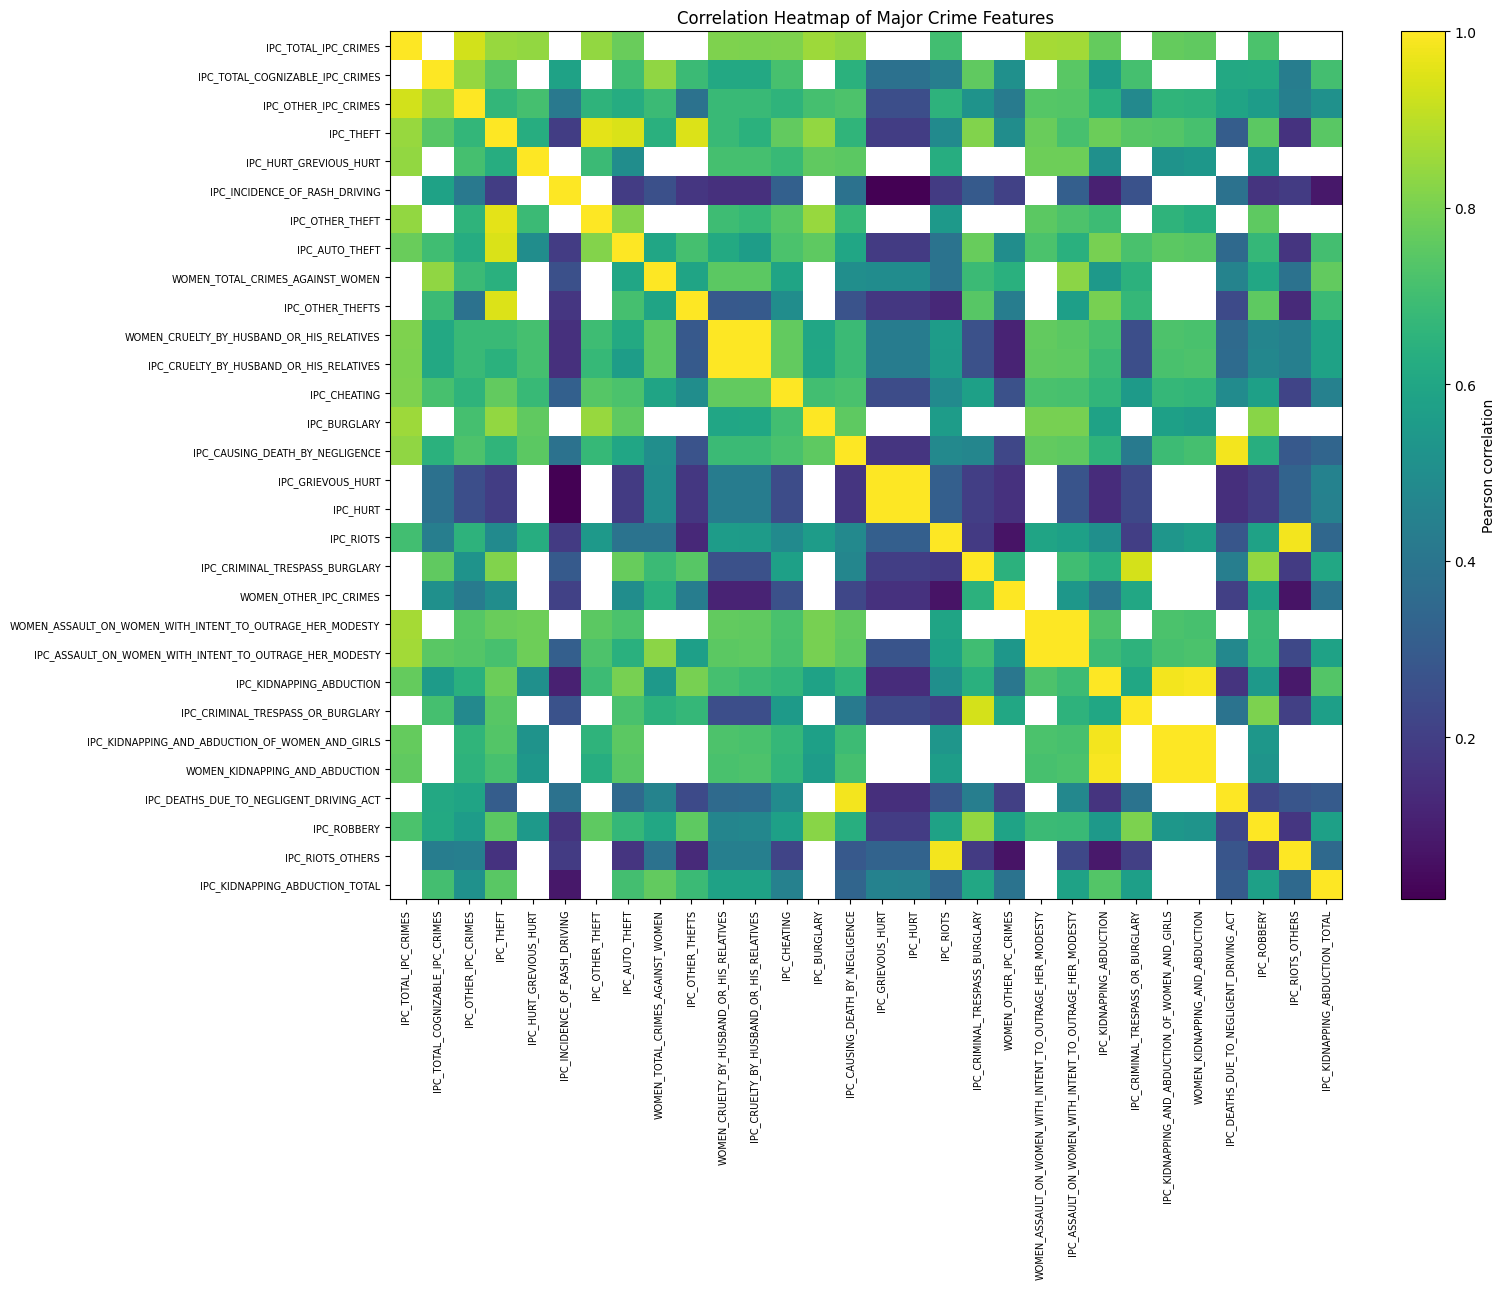

In [33]:
# ============================================================
# CELL 33 — CORRELATION HEATMAP
# ============================================================

plt.figure(figsize=(16, 13))

plt.imshow(
    correlation_matrix,
    aspect="auto"
)

plt.colorbar(
    label="Pearson correlation"
)

plt.xticks(
    range(len(correlation_features)),
    correlation_features,
    rotation=90,
    fontsize=7
)

plt.yticks(
    range(len(correlation_features)),
    correlation_features,
    fontsize=7
)

plt.title(
    "Correlation Heatmap of Major Crime Features"
)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR /
    "eda_crime_feature_correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [34]:
# ============================================================
# CELL 35 — OUTLIER ANALYSIS
# ============================================================

outlier_records = []

for col in numeric_crime_columns:

    series = pd.to_numeric(
        df[col],
        errors="coerce"
    ).dropna()

    if len(series) < 10:
        continue

    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)

    iqr = q3 - q1

    lower_bound = (
        q1 - 1.5 * iqr
    )

    upper_bound = (
        q3 + 1.5 * iqr
    )

    outlier_mask = (
        (series < lower_bound) |
        (series > upper_bound)
    )

    outlier_count = int(
        outlier_mask.sum()
    )

    outlier_records.append({

        "feature":
            col,

        "q1":
            q1,

        "q3":
            q3,

        "iqr":
            iqr,

        "upper_bound":
            upper_bound,

        "outlier_count":
            outlier_count,

        "outlier_pct":
            round(
                100 *
                outlier_count /
                len(series),
                2
            )
    })

outlier_summary = pd.DataFrame(
    outlier_records
)

outlier_summary = (
    outlier_summary
    .sort_values(
        "outlier_count",
        ascending=False
    )
    .reset_index(drop=True)
)

print("=" * 80)
print("OUTLIER ANALYSIS")
print("=" * 80)

display(
    outlier_summary.head(30)
)

outlier_summary.to_csv(
    TABLES_DIR /
    "eda_outlier_summary.csv",
    index=False,
    encoding="utf-8-sig"
)

OUTLIER ANALYSIS


,feature,q1,q3,iqr,upper_bound,outlier_count,outlier_pct
0,ST_RAPE,0.0,0.0,0.0,0.0,2151,24.20
1,ST_HURT,0.0,0.0,0.0,0.0,1967,22.13
2,SC_KIDNAPPING_AND_ABDUCTION,0.0,0.0,0.0,0.0,1913,21.61
3,ST_PREVENTION_OF_ATROCITIES_POA_ACT,0.0,0.0,0.0,0.0,1873,21.07
4,CHILDREN_EXPOSURE_AND_ABANDONMENT,0.0,0.0,0.0,0.0,1749,19.75
5,ST_OTHER_CRIMES_AGAINST_STS,0.0,2.0,2.0,5.0,1576,17.73
6,CHILDREN_OTHER_CRIMES,0.0,4.0,4.0,10.0,1473,16.64
7,SC_ARSON,0.0,0.0,0.0,0.0,1416,15.99
8,SC_PREVENTION_OF_ATROCITIES_POA_ACT,0.0,14.0,14.0,35.0,1193,13.48
9,IPC_PREPARATION_AND_ASSEMBLY_FOR_DACOITY,0.0,2.0,2.0,5.0,1148,12.90


In [35]:
# ============================================================
# CELL 36 — YEARLY CRIME-FAMILY AVAILABILITY
# ============================================================

availability_by_year = (
    df
    .groupby("YEAR")[
        availability_columns
    ]
    .mean()
    * 100
)

availability_by_year.columns = [
    col.replace(
        "_AVAILABLE",
        ""
    )
    for col in availability_by_year.columns
]

availability_by_year = (
    availability_by_year
    .round(2)
)

print("=" * 80)
print("YEARLY CRIME-FAMILY AVAILABILITY (%)")
print("=" * 80)

display(
    availability_by_year
)

availability_by_year.to_csv(
    TABLES_DIR /
    "eda_yearly_crime_family_availability.csv",
    encoding="utf-8-sig"
)

YEARLY CRIME-FAMILY AVAILABILITY (%)


,IPC,SC,ST,CHILDREN,WOMEN
YEAR,,,,,
2001,97.31,96.86,96.86,97.31,97.31
2002,97.03,96.88,96.88,97.03,97.03
2003,96.21,96.06,96.06,96.50,96.21
2004,97.06,96.92,96.92,97.06,97.06
2005,97.94,97.79,97.79,97.94,97.94
2006,97.94,97.80,97.80,97.94,97.94
2007,97.81,97.66,97.66,97.81,97.81
2008,97.03,96.88,96.88,96.88,97.03
2009,97.05,96.91,96.91,96.91,97.05


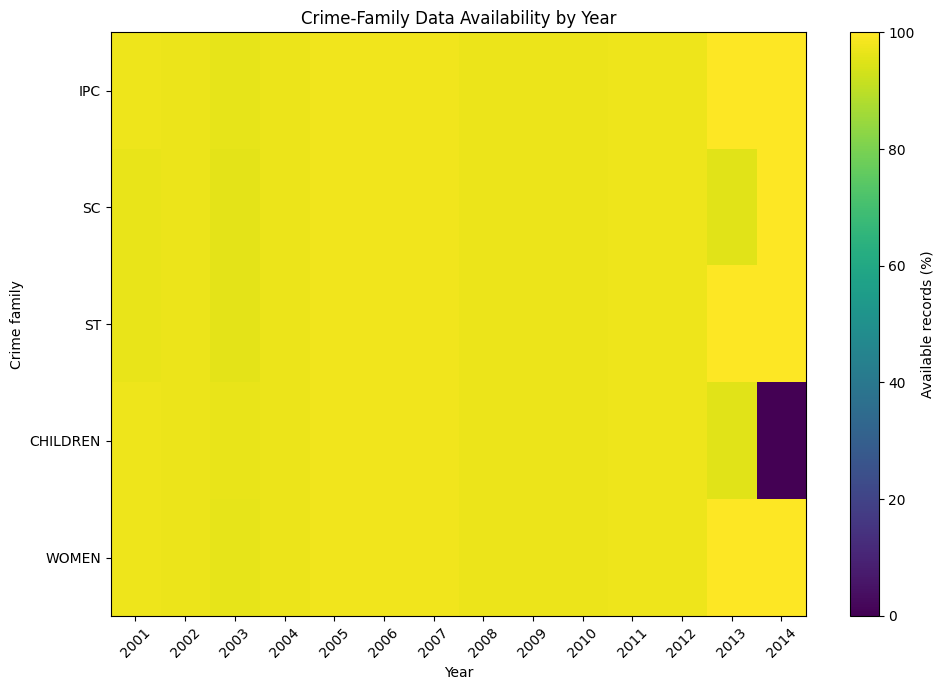

In [36]:
# ============================================================
# CELL 37 — AVAILABILITY HEATMAP
# ============================================================

plt.figure(figsize=(10, 7))

plt.imshow(
    availability_by_year.T,
    aspect="auto"
)

plt.colorbar(
    label="Available records (%)"
)

plt.xticks(
    range(len(availability_by_year.index)),
    availability_by_year.index,
    rotation=45
)

plt.yticks(
    range(len(availability_by_year.columns)),
    availability_by_year.columns
)

plt.xlabel("Year")
plt.ylabel("Crime family")

plt.title(
    "Crime-Family Data Availability by Year"
)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR /
    "eda_crime_family_availability_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [37]:
# ============================================================
# CELL 38 — STATE-YEAR RECORD COVERAGE
# ============================================================

state_year_counts = (
    df
    .pivot_table(
        index="STATE",
        columns="YEAR",
        values="UNIT_NAME",
        aggfunc="count",
        fill_value=0
    )
)

print("=" * 80)
print("STATE-YEAR RECORD COVERAGE")
print("=" * 80)

display(
    state_year_counts.head(30)
)

state_year_counts.to_csv(
    TABLES_DIR /
    "eda_state_year_record_coverage.csv",
    encoding="utf-8-sig"
)

STATE-YEAR RECORD COVERAGE


YEAR,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014
STATE,,,,,,,,,,,,,,
A & N ISLANDS,2,2,2,2,2,2,1,2,2,2,2,3,0,0
A&N Islands,0,0,0,0,0,0,0,0,0,0,0,0,4,3
ANDHRA PRADESH,26,26,27,27,27,26,26,26,26,27,27,27,0,0
ARUNACHAL PRADESH,13,13,15,15,15,15,15,15,16,16,16,16,0,0
ASSAM,27,26,26,26,29,29,29,29,29,29,29,31,0,0
Andhra Pradesh,0,0,0,0,0,0,0,0,0,0,0,0,28,14
Arunachal Pradesh,0,0,0,0,0,0,0,0,0,0,0,0,18,17
Assam,0,0,0,0,0,0,0,0,0,0,0,0,33,27
BIHAR,44,44,44,44,44,44,44,44,44,44,44,44,0,0


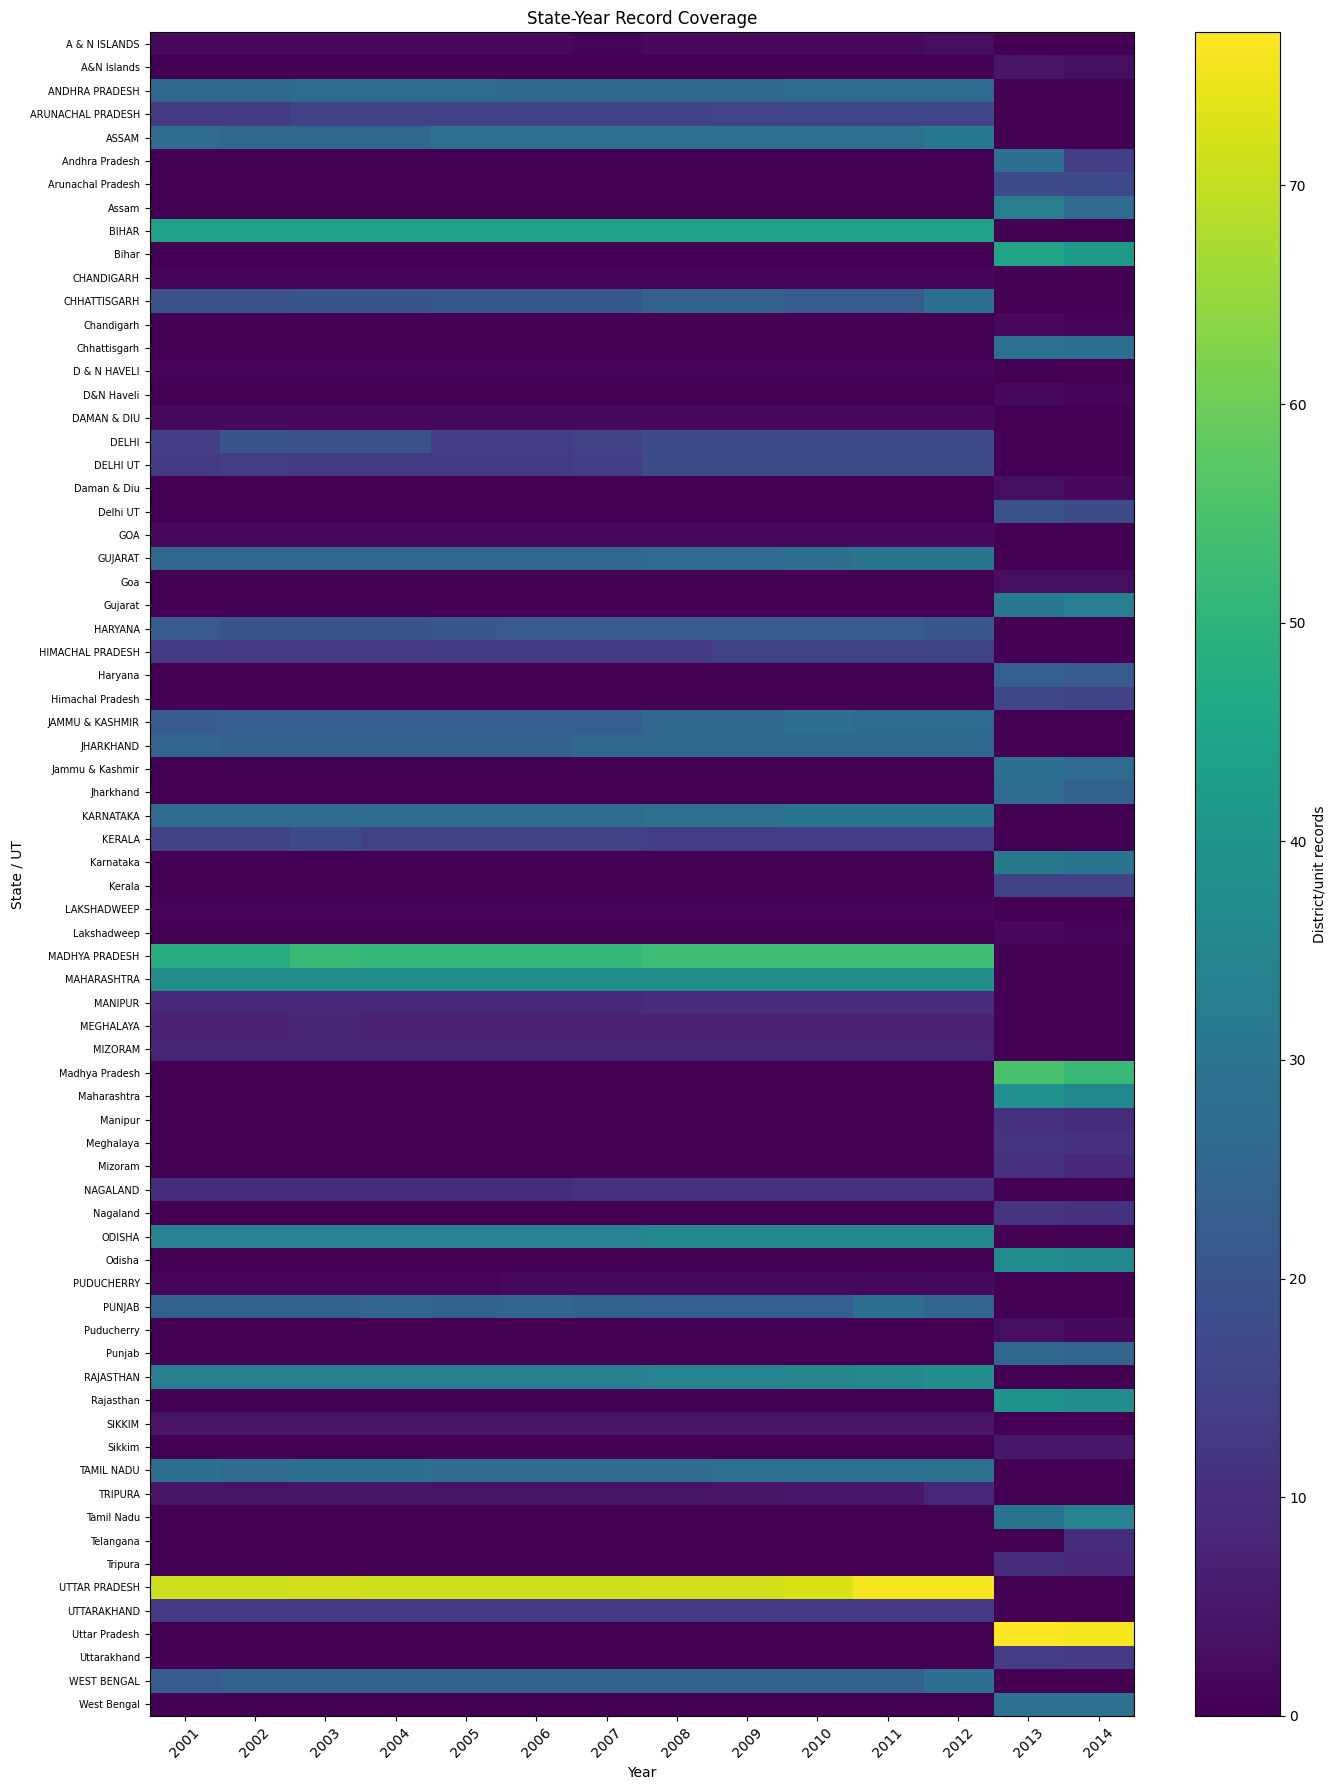

In [38]:
# ============================================================
# CELL 39 — STATE-YEAR COVERAGE HEATMAP
# ============================================================

plt.figure(figsize=(14, 18))

plt.imshow(
    state_year_counts,
    aspect="auto"
)

plt.colorbar(
    label="District/unit records"
)

plt.xticks(
    range(len(state_year_counts.columns)),
    state_year_counts.columns,
    rotation=45
)

plt.yticks(
    range(len(state_year_counts.index)),
    state_year_counts.index,
    fontsize=7
)

plt.xlabel("Year")
plt.ylabel("State / UT")

plt.title(
    "State-Year Record Coverage"
)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR /
    "eda_state_year_coverage_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [39]:
# ============================================================
# CELL 40 — FINAL EDA SUMMARY
# ============================================================

eda_summary = pd.DataFrame({

    "metric": [
        "Rows",
        "Columns",
        "Years",
        "States / UTs",
        "District / Unit names",
        "Crime families",
        "Numeric crime features",
        "Columns with missing values",
        "Columns without missing values",
        "Duplicate rows",
        "Duplicate integration keys"
    ],

    "value": [
        len(df),
        len(df.columns),
        df["YEAR"].nunique(),
        df["STATE"].nunique(),
        df["UNIT_NAME"].nunique(),
        len(crime_families),
        len(numeric_crime_columns),
        int(
            (missing_summary["missing_count"] > 0).sum()
        ),
        int(
            (missing_summary["missing_count"] == 0).sum()
        ),
        int(df.duplicated().sum()),
        int(
            df.duplicated(
                KEY_COLUMNS
            ).sum()
        )
    ]
})

print("=" * 80)
print("FINAL EDA SUMMARY")
print("=" * 80)

display(
    eda_summary
)

eda_summary.to_csv(
    TABLES_DIR /
    "final_eda_summary.csv",
    index=False,
    encoding="utf-8-sig"
)

FINAL EDA SUMMARY


,metric,value
0,Rows,9856
1,Columns,331
2,Years,14
3,States / UTs,72
4,District / Unit names,1490
5,Crime families,5
6,Numeric crime features,323
7,Columns with missing values,323
8,Columns without missing values,8
9,Duplicate rows,0


In [40]:
# ============================================================
# CELL 41 — EDA FINDINGS
# ============================================================

highest_missing_feature = (
    missing_summary.iloc[0]
)

most_zero_dominated = (
    zero_summary.iloc[0]
)

highest_outlier_feature = (
    outlier_summary.iloc[0]
)

print("=" * 80)
print("FINAL EXPLORATORY DATA ANALYSIS FINDINGS")
print("=" * 80)

print(
    f"""
1. Dataset structure
   The finalized integrated dataset contains
   {len(df):,} district-year records and
   {len(df.columns):,} columns.

2. Temporal coverage
   The dataset covers {int(df['YEAR'].min())}
   to {int(df['YEAR'].max())}, representing
   {df['YEAR'].nunique()} years.

3. Geographic coverage
   The dataset contains {df['STATE'].nunique()}
   state/UT labels and
   {df['UNIT_NAME'].nunique():,} district/unit names.

4. Crime-family structure
   The integrated dataset contains five crime families:
   IPC, SC, ST, CHILDREN and WOMEN.

5. Missingness
   {int((missing_summary['missing_count'] > 0).sum())}
   of {len(df.columns)} columns contain missing values.
   Missingness is concentrated in schema-dependent
   crime-family features.

6. Highest observed missingness
   {highest_missing_feature['column']}
   has {highest_missing_feature['missing_pct']:.2f}%
   missing values.

7. Zero-valued observations
   The feature with the highest observed zero proportion
   is {most_zero_dominated['feature']},
   with {most_zero_dominated['zero_pct_observed']:.2f}%
   of its observed values equal to zero.

8. Outliers
   The IQR-based descriptive analysis identifies
   {highest_outlier_feature['feature']} as having the
   largest number of observations beyond its IQR bounds.

9. Data integrity
   Duplicate rows: {df.duplicated().sum():,}
   Duplicate STATE + UNIT_NAME + YEAR keys:
   {df.duplicated(KEY_COLUMNS).sum():,}

10. Important interpretation
    Missing values have been retained during EDA.
    No blanket zero-imputation or statistical imputation
    has been performed in this notebook.
"""
)

FINAL EXPLORATORY DATA ANALYSIS FINDINGS

1. Dataset structure
   The finalized integrated dataset contains
   9,856 district-year records and
   331 columns.

2. Temporal coverage
   The dataset covers 2001
   to 2014, representing
   14 years.

3. Geographic coverage
   The dataset contains 72
   state/UT labels and
   1,490 district/unit names.

4. Crime-family structure
   The integrated dataset contains five crime families:
   IPC, SC, ST, CHILDREN and WOMEN.

5. Missingness
   323
   of 331 columns contain missing values.
   Missingness is concentrated in schema-dependent
   crime-family features.

6. Highest observed missingness
   SC_TOTAL_CRIMES_AGAINST_SCS
   has 92.61%
   missing values.

7. Zero-valued observations
   The feature with the highest observed zero proportion
   is SC_POA_DACOITY_WITH_MURDER,
   with 100.00%
   of its observed values equal to zero.

8. Outliers
   The IQR-based descriptive analysis identifies
   ST_RAPE as having the
   largest number of observa

In [41]:
# ============================================================
# CELL 42 — EDA OUTPUT INDEX
# ============================================================

eda_output_index = pd.DataFrame({

    "output_type": [
        "Dataset profile",
        "Year summary",
        "State summary",
        "Unit summary",
        "Missing-value summary",
        "Crime-family availability",
        "Numeric feature statistics",
        "Total crime feature summary",
        "Top crime features",
        "Zero-value analysis",
        "Correlation matrix",
        "Strong correlations",
        "Outlier analysis",
        "Yearly family availability",
        "State-year coverage",
        "Final EDA summary"
    ],

    "location": [
        "outputs/tables/eda_dataset_profile.csv",
        "outputs/tables/eda_year_summary.csv",
        "outputs/tables/eda_state_summary.csv",
        "outputs/tables/eda_unit_summary.csv",
        "outputs/tables/eda_missing_value_summary.csv",
        "outputs/tables/eda_crime_family_availability.csv",
        "outputs/tables/eda_numeric_descriptive_statistics.csv",
        "outputs/tables/eda_total_crime_feature_summary.csv",
        "outputs/tables/eda_top_crime_features_by_sum.csv",
        "outputs/tables/eda_zero_value_summary.csv",
        "outputs/tables/eda_correlation_matrix.csv",
        "outputs/tables/eda_strong_feature_correlations.csv",
        "outputs/tables/eda_outlier_summary.csv",
        "outputs/tables/eda_yearly_crime_family_availability.csv",
        "outputs/tables/eda_state_year_record_coverage.csv",
        "outputs/tables/final_eda_summary.csv"
    ]
})

display(
    eda_output_index
)

eda_output_index.to_csv(
    TABLES_DIR /
    "eda_output_index.csv",
    index=False,
    encoding="utf-8-sig"
)

print(
    "\n✓ EDA outputs indexed and saved."
)

,output_type,location
0,Dataset profile,outputs/tables/eda_dataset_profile.csv
1,Year summary,outputs/tables/eda_year_summary.csv
2,State summary,outputs/tables/eda_state_summary.csv
3,Unit summary,outputs/tables/eda_unit_summary.csv
4,Missing-value summary,outputs/tables/eda_missing_value_summary.csv
5,Crime-family availability,outputs/tables/eda_crime_family_availability.csv
6,Numeric feature statistics,outputs/tables/eda_numeric_descriptive_statistics.csv
7,Total crime feature summary,outputs/tables/eda_total_crime_feature_summary.csv
8,Top crime features,outputs/tables/eda_top_crime_features_by_sum.csv
9,Zero-value analysis,outputs/tables/eda_zero_value_summary.csv



✓ EDA outputs indexed and saved.
